# 💊 PhARMA RAG — The Final Notebook

### Every stage of the production pipeline, the reason it is built that way, and the measurement that justifies it

---

This notebook is the **single reference document** for the PhARMA RAG system: a
Retrieval-Augmented Generation pipeline over **506 real FDA drug labels**, written from
scratch — no LangChain, no LlamaIndex, no Chroma — so that every decision is visible and
independently checkable.

The system answers drug questions **only** from retrieved label text, **cites every source**,
and **refuses** when the corpus cannot support an answer.

> ⚠️ **Educational project. Not medical advice.** Every answer carries a disclaimer and cites
> the exact chunks it used.

---

## What makes this notebook different

This repository previously carried three teaching notebooks (*Pipeline*, *Learning Edition*,
*Scale Edition*). Each **re-implemented** the pipeline inline, which is excellent for learning a
concept once but means four copies of the logic that drift apart the moment production changes.

**This notebook imports the real modules instead.**

```python
from stages import load
retrieval = load("06_retrieve_context")   # the actual file the Streamlit app runs
```

Every number below is produced by the same code that serves users. If `ALPHA` changes in
`06_retrieve_context.py`, this notebook reports the new value on the next run — it cannot go
stale, and it cannot flatter the system with numbers the product doesn't actually achieve.

## How to read it

Each stage follows the same three-beat structure:

| Beat | Question it answers |
|---|---|
| 🎯 **Why this stage exists** | What breaks without it |
| ⚙️ **The decision** | What was chosen, and what was rejected |
| 📊 **The evidence** | The measurement that justifies the choice — run live |

Design choices that were **rejected** are documented alongside the ones that were kept, with the
measurement that decided it. Negative results are kept, not hidden: they are the reason to trust
the positive ones.

## Contents

| Part | Stage | The core question |
|---|---|---|
| **0** | Setup & architecture | What are the moving parts? |
| **1** | `01_documents.py` | How does anything become retrievable text? |
| **2** | `02_preprocessing.py` | Why is "clean your text" *dangerous* here? |
| **3** | `03_chunking.py` | How big is a retrievable unit, and why? |
| **4** | `04_vector_representation.py` | Why **two** representations instead of one? |
| **5** | `05_create_vector_store.py` | Why FAISS, and why not a vector database? |
| **6** | `06_retrieve_context.py` | **How is the system stopped from answering confidently and wrongly?** |
| **7** | `07_prompting.py` | How is "the answer came from the sources" *proved*? |
| **8** | Evaluation | Does any of this actually work? |
| **9** | Decision ledger | What would change these answers? |

Part 6 is the heart of the project. Everything before it exists to make it possible; everything
after it exists to verify it.

---
# Part 0 — Setup

## 🎯 Why a loader instead of plain imports

`import 01_documents` is a **`SyntaxError`** — Python module names may not begin with a digit.

But the numbered filenames are worth keeping: a directory listing that reads
`01_documents → 02_preprocessing → … → 07_prompting` *is* the architecture diagram, and every
file stays independently runnable (`python 03_chunking.py`), which is what lets each stage be
demonstrated on its own.

Those two goals collide, and `stages.py` resolves the collision: it imports a numbered file **by
path** and caches the module object, so stages reuse each other instead of copy-pasting, while
each file still runs standalone. It is ~40 lines of deliberate plumbing.

In [1]:
import sys, time, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

warnings.filterwarnings("ignore")
%matplotlib inline

# Repo root — works whether the notebook is opened from the repo or elsewhere.
ROOT = Path.cwd()
if not (ROOT / "stages.py").exists():
    ROOT = Path(r"C:\Users\Admin\Drag_Rag") if Path(r"C:\Users\Admin\Drag_Rag").exists() else ROOT
sys.path.insert(0, str(ROOT))

from stages import load   # noqa: E402

# The seven production stages — the SAME modules the Streamlit app imports.
documents_stage = load("01_documents")
preprocessing   = load("02_preprocessing")
chunking        = load("03_chunking")
representation  = load("04_vector_representation")
vector_store    = load("05_create_vector_store")
retrieval       = load("06_retrieve_context")
prompting       = load("07_prompting")

print(f"repo root : {ROOT}")
print(f"python    : {sys.version.split()[0]}")
print("stages loaded: 01 → 07  (imported, not re-implemented)")

repo root : C:\Users\Admin\Drag_Rag
python    : 3.11.15
stages loaded: 01 → 07  (imported, not re-implemented)


### Plot theme

One place for colour and typography, so every figure below reads as part of the same document.
The palette is semantic and used consistently throughout:

- 🟠 **orange = sparse / lexical** (BM25, TF-IDF)
- 🔵 **blue = dense / semantic** (embeddings)
- 🟢 **green = hybrid** (the blend the system actually ships)
- 🔴 **red = unsafe / rejected / refused**

In [2]:
FIGDIR = ROOT / "docs" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

INK, MUTED, GRID, PAPER = "#111827", "#6b7280", "#e5e7eb", "#ffffff"
SPARSE, DENSE, HYBRID   = "#ea580c", "#2563eb", "#059669"   # lexical / semantic / blend
DANGER, GOLD, SLATE     = "#dc2626", "#d97706", "#475569"

plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.titlepad": 12, "figure.dpi": 110,
})

def save(fig, name):
    """Write the figure to docs/figures/ so the README and slides can reuse it."""
    fig.savefig(FIGDIR / f"{name}.png", dpi=150, bbox_inches="tight", facecolor=PAPER)
    return fig

print(f"figures → {FIGDIR}")

figures → C:\Users\Admin\Drag_Rag\docs\figures


## 🎯 Graceful degradation is a feature, not an accident

Every optional dependency in this project has a fallback, and the app is designed to *keep
working* when one is missing:

| Missing | Consequence |
|---|---|
| `sentence-transformers` / `torch` | dense retrieval off → **BM25-only**, still fully functional |
| `faiss-cpu` | dense search falls back to a NumPy matmul — identical maths, slightly slower |
| `rank_bm25` | falls back to a hand-written BM25-Okapi kept from the notebooks |
| `nltk` corpora | tokenizer → `str.split()`, stopwords → scikit-learn's list |
| every LLM provider | **extractive mode** — retrieved text shown verbatim, still cited |

The reason is deployment reality: Streamlit Community Cloud rebuilds the container from scratch,
and a blocked NLTK download or a missing torch wheel would otherwise take the whole app down. The
pipeline degrades in *quality*, never in *trustworthiness*.

The cell below reports which path this particular run is taking, so nothing below is ambiguous.

In [3]:
def dep(mod):
    try:
        __import__(mod); return True
    except Exception:
        return False

env = {
    "sentence-transformers": dep("sentence_transformers"),
    "torch":                 dep("torch"),
    "faiss-cpu":             dep("faiss"),
    "rank_bm25":             dep("rank_bm25"),
    "nltk":                  dep("nltk"),
    "scikit-learn":          dep("sklearn"),
}
for name, ok in env.items():
    print(f"  {'✅' if ok else '⚠️ '} {name:24s} {'available' if ok else 'MISSING → fallback path'}")

print(f"\n  preprocessing profile : {preprocessing.DEFAULT_PROFILE_NAME}")
print(f"  stopword source       : {preprocessing.STOPWORD_SOURCE}")
print(f"  NLTK available        : {preprocessing.NLTK_AVAILABLE}")

  ✅ sentence-transformers    available
  ✅ torch                    available
  ✅ faiss-cpu                available
  ✅ rank_bm25                available
  ✅ nltk                     available
  ✅ scikit-learn             available

  preprocessing profile : readable_lemmatized
  stopword source       : nltk
  NLTK available        : True


## The architecture, generated from live constants

The diagram below is **not a drawing**. It is rendered from a data structure whose right-hand
parameter column is read out of the imported modules at run time — `α` comes from
`retrieval.ALPHA`, the chunk size from `chunking.CHUNK_WORDS`, the model name from
`representation.EMBED_MODEL_NAME`, the IVF threshold from `vector_store.IVF_THRESHOLD`.

That matters: a hand-drawn architecture diagram starts lying the first time someone tunes a
constant. This one cannot drift out of sync with the code, because it *is* the code.

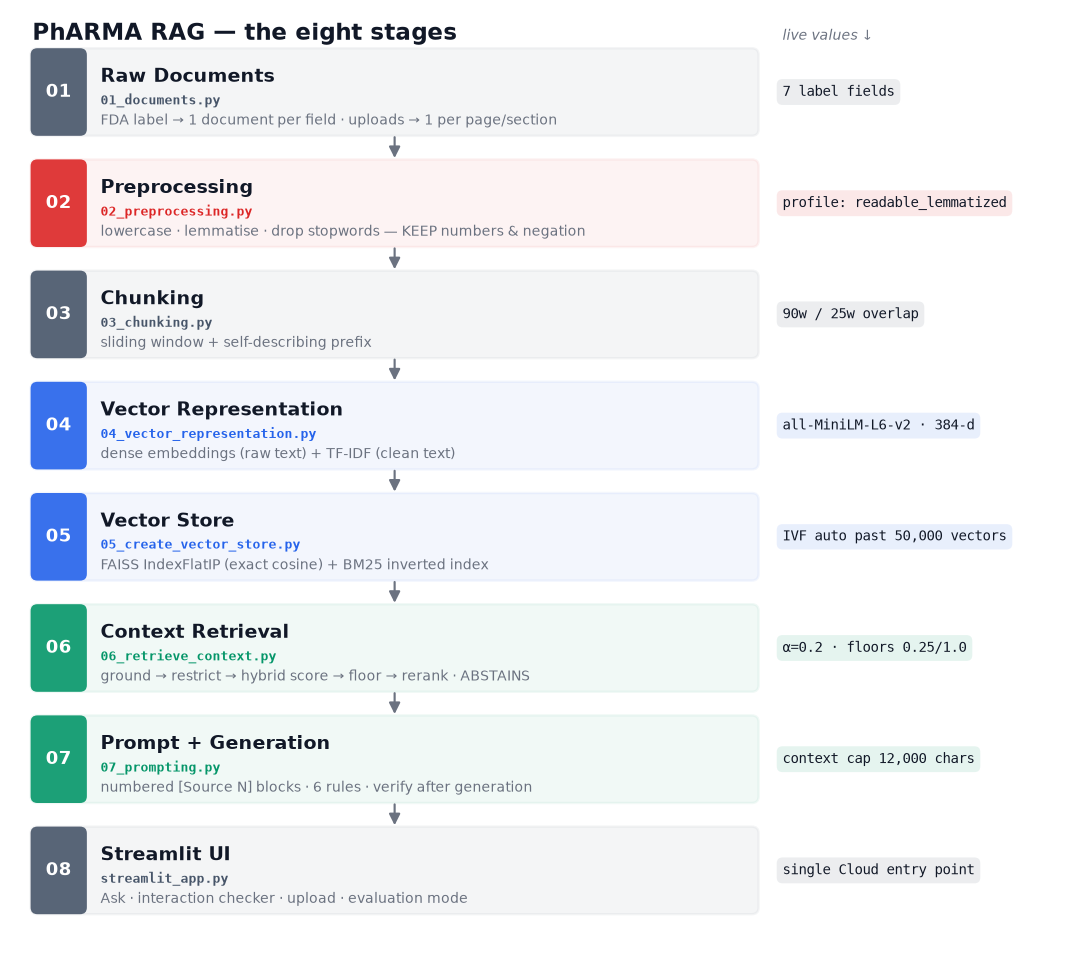

In [4]:
STAGES = [
    ("01", "Raw Documents",        "01_documents.py",
     "FDA label → 1 document per field · uploads → 1 per page/section",
     f"{len(documents_stage.FIELD_LABELS)} label fields"),
    ("02", "Preprocessing",        "02_preprocessing.py",
     "lowercase · lemmatise · drop stopwords — KEEP numbers & negation",
     f"profile: {preprocessing.DEFAULT_PROFILE_NAME}"),
    ("03", "Chunking",             "03_chunking.py",
     "sliding window + self-describing prefix",
     f"{chunking.CHUNK_WORDS}w / {chunking.CHUNK_OVERLAP}w overlap"),
    ("04", "Vector Representation","04_vector_representation.py",
     "dense embeddings (raw text) + TF-IDF (clean text)",
     f"{representation.EMBED_MODEL_NAME} · {representation.EMBED_DIM}-d"),
    ("05", "Vector Store",         "05_create_vector_store.py",
     "FAISS IndexFlatIP (exact cosine) + BM25 inverted index",
     f"IVF auto past {vector_store.IVF_THRESHOLD:,} vectors"),
    ("06", "Context Retrieval",    "06_retrieve_context.py",
     "ground → restrict → hybrid score → floor → rerank · ABSTAINS",
     f"α={retrieval.ALPHA} · floors {retrieval.EMB_FLOOR}/{retrieval.BM25_FLOOR}"),
    ("07", "Prompt + Generation",  "07_prompting.py",
     "numbered [Source N] blocks · 6 rules · verify after generation",
     f"context cap {prompting.MAX_CONTEXT_CHARS:,} chars"),
    ("08", "Streamlit UI",         "streamlit_app.py",
     "Ask · interaction checker · upload · evaluation mode",
     "single Cloud entry point"),
]

fig, ax = plt.subplots(figsize=(12.5, 11))
ax.set_xlim(0, 12.5); ax.set_ylim(0, len(STAGES) * 1.32 + 0.5)
ax.axis("off"); ax.grid(False)

accent = [SLATE, DANGER, SLATE, DENSE, DENSE, HYBRID, HYBRID, SLATE]

for i, (num, name, fname, what, param) in enumerate(STAGES):
    y = (len(STAGES) - 1 - i) * 1.32 + 0.35
    c = accent[i]
    ax.add_patch(FancyBboxPatch((0.25, y), 8.5, 1.0, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=c, alpha=0.055, edgecolor=c, linewidth=1.6))
    ax.add_patch(FancyBboxPatch((0.25, y), 0.62, 1.0, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=c, alpha=0.9, edgecolor="none"))
    ax.text(0.56, y + 0.5, num, ha="center", va="center", color="white",
            fontsize=12, fontweight="bold")
    ax.text(1.05, y + 0.68, name, fontsize=12.5, fontweight="bold", color=INK, va="center")
    ax.text(1.05, y + 0.40, fname, fontsize=8.5, color=c, va="center",
            family="monospace", fontweight="bold")
    ax.text(1.05, y + 0.16, what, fontsize=9, color=MUTED, va="center")
    # live parameter column
    ax.text(9.05, y + 0.5, param, fontsize=9, color=INK, va="center",
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.42", facecolor=c, alpha=0.10, edgecolor="none"))
    if i < len(STAGES) - 1:
        ax.add_patch(FancyArrowPatch((4.5, y), (4.5, y - 0.32),
                                     arrowstyle="-|>", mutation_scale=15,
                                     color=MUTED, linewidth=1.4))

ax.text(0.25, len(STAGES) * 1.32 + 0.15, "PhARMA RAG — the eight stages",
        fontsize=15, fontweight="bold", color=INK)
ax.text(9.05, len(STAGES) * 1.32 + 0.15, "live values ↓", fontsize=9,
        color=MUTED, style="italic")

save(fig, "01_architecture"); plt.show()

> **Read the diagram as a funnel of trust.** Stages 01–05 build an index — they are ordinary
> engineering and any mistake there is a *quality* bug. Stage 06 is where the system earns the
> right to answer at all, and stage 07 is where it is held to that. The two green stages are the
> ones a clinical buyer would actually audit.

---
# Part 1 — Stage 01 · Raw Documents

## 🎯 Why this stage exists

Retrieval cannot find a fact that was never ingested, and the LLM is forbidden (by the prompt in
stage 07) from using anything except what retrieval returns. So the ceiling on the entire system
is set here.

Two very different sources have to arrive at the same shape:

1. **The built-in corpus** — 506 openFDA labels, structured JSON with named fields.
2. **User uploads** — PDF / DOCX / TXT / MD / CSV / JSON: unstructured blobs with no fields at all.

A single `Document` dataclass (`doc_id`, `title`, `field`, `category`, `text`, `origin`) is the
common shape, so stages 02–07 never have to care where text came from. An uploaded PDF flows
through chunking → embedding → retrieval → citation with **zero special-casing downstream**.

## ⚙️ The decision: one document per *field*, not one per drug

A whole drug label is ~3,000 words spanning mechanism, dosing, warnings and interactions.
Embedding that as one vector produces a **blurry average** — it matches every drug question
weakly and none of them strongly.

An FDA Structured Product Label has already been split by its authors into
`description · mechanism · indications · dosage · side_effects · contraindications · interactions`.

Splitting on the label's own boundaries is therefore **free, semantically perfect chunking**:
each document already contains exactly one coherent topic, and the field name becomes citation
metadata — a source reads *"metformin · dosage"* rather than *"chunk #4127"*.

In [5]:
records = documents_stage.load_drug_records()
docs    = documents_stage.documents_from_drug_records(records)
stats   = documents_stage.corpus_stats(docs)

print(f"corpus file    : {documents_stage.default_corpus_path().name}")
print(f"drug records   : {len(records):,}")
print(f"documents      : {stats['documents']:,}   (one per populated field)")
print(f"unique sources : {stats['sources']:,}")
print(f"total words    : {stats['total_words']:,}")
print(f"words/document : mean {stats['mean_words']}, max {stats['max_words']:,}")

sample = docs[0]
print(f"\nsample document — {sample.doc_id}")
print(f"  title  : {sample.title}")
print(f"  field  : {sample.field}")
print(f"  origin : {sample.origin}")
print(f"  text   : {sample.text[:180]}…")

corpus file    : drugs_large.json
drug records   : 506
documents      : 3,472   (one per populated field)
unique sources : 506
total words    : 934,850
words/document : mean 269.3, max 759

sample document — naproxen::description
  title  : Naproxen
  field  : description
  origin : drug-corpus
  text   : 11 DESCRIPTION Naproxen Tablets, USP and Naproxen Sodium Tablets, USP are nonsteroidal anti-inflammatory drugs available as follows: Naproxen Tablets, USP are available as follows …


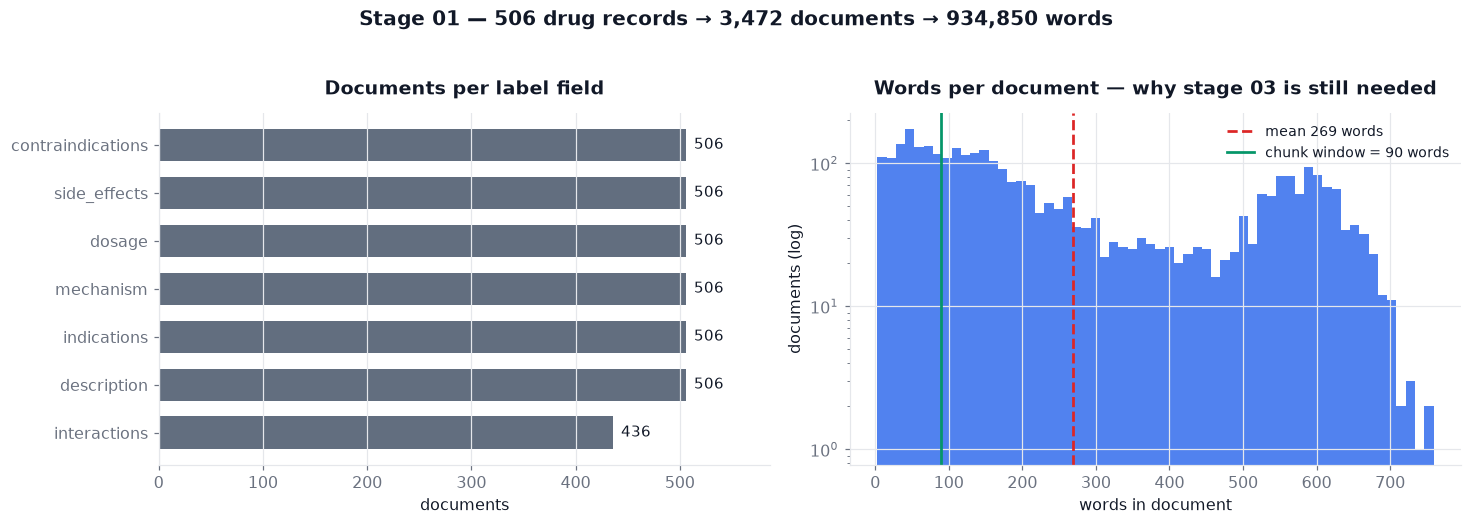

In [6]:
by_field = pd.Series(stats["by_field"]).sort_values()
words    = np.array([d.word_count for d in docs])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

ax = axes[0]
ax.barh(by_field.index, by_field.values, color=SLATE, alpha=0.85, height=0.68)
for y, v in enumerate(by_field.values):
    ax.text(v + max(by_field.values) * 0.015, y, f"{v:,}", va="center", fontsize=9.5, color=INK)
ax.set_title("Documents per label field")
ax.set_xlabel("documents"); ax.set_xlim(0, max(by_field.values) * 1.16)
ax.grid(axis="y", visible=False)

ax = axes[1]
ax.hist(words, bins=60, color=DENSE, alpha=0.8)
ax.axvline(words.mean(), color=DANGER, linestyle="--", linewidth=1.8,
           label=f"mean {words.mean():.0f} words")
ax.axvline(chunking.CHUNK_WORDS, color=HYBRID, linestyle="-", linewidth=1.8,
           label=f"chunk window = {chunking.CHUNK_WORDS} words")
ax.set_yscale("log")
ax.set_title("Words per document — why stage 03 is still needed")
ax.set_xlabel("words in document"); ax.set_ylabel("documents (log)")
ax.legend(frameon=False, fontsize=9)

fig.suptitle(f"Stage 01 — {len(records):,} drug records → {len(docs):,} documents → "
             f"{stats['total_words']:,} words",
             fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout(); save(fig, "02_corpus_shape"); plt.show()

### 📊 What just happened

Field-splitting alone got us from 506 records to **3,472 documents** — a 6.9× gain in retrieval
granularity for **zero** engineering cost, purely by respecting boundaries the FDA had already
drawn.

But the right-hand histogram is the important one: the distribution runs far past the green line
marking the 90-word embedding window. **Most documents are still too long to embed as a single
vector.** Field-splitting was necessary and is not sufficient — which is precisely the argument
for stage 03.

---
# Part 2 — Stage 02 · Preprocessing

## 🎯 Why this is the most dangerous file in the project

Lexical retrieval matches **literal tokens**. Without normalisation, `"Doses"`, `"doses"` and
`"dosing"` are three unrelated words, and a query for one will not find the others. So some
cleaning is required.

The problem is that the textbook recipe — *lowercase, strip punctuation, drop stopwords, drop
numbers, stem* — is **actively harmful** on clinical text. Consider a real label sentence:

> *"No known hepatotoxicity at therapeutic doses (500 mg). Not recommended with warfarin."*

| Standard step | What it does here |
|---|---|
| drop stopwords | deletes **"No"** and **"Not"** → the sentence now asserts the **opposite** |
| drop numbers | deletes **"500"** → the dose is gone |
| stem | `hepatotoxicity` → `hepatotox` |

A stopword list is built for *topic* search, where "not" carries no topic signal. Clinical text is
the opposite case: **negation is the content**. `"No known interactions"` and
`"known interactions"` are opposite facts and must never collapse to the same token sequence.

## ⚙️ The decision: preprocessing is a safety control, not a tuning knob

Two guarantees are hard-coded into the default profile and **asserted in code**:

1. `PROTECTED_NEGATION` words are never removed and never stemmed.
2. Numbers are never removed.

The unsafe `aggressive_stemmed` profile is *kept* — not used — so the damage can be
**demonstrated** rather than asserted. A claim you can run is worth more than a comment.

> **Scope note:** only the *lexical* index consumes this cleaned text. The dense embedding model in
> stage 04 is deliberately fed the **raw** text, because transformers are trained on natural
> language and are hurt, not helped, by stopword removal.

In [7]:
print("PROTECTED_NEGATION:", sorted(preprocessing.PROTECTED_NEGATION), "\n")
print("Original sentence:")
print(" ", preprocessing.SAFETY_SENTENCE, "\n")

report = preprocessing.safety_report()
for name, r in report.items():
    safe = r["keeps_negation"] and r["keeps_numbers"]
    tag  = "✅ SAFE  " if safe else "⚠️  UNSAFE"
    used = "  ← pipeline default" if name == preprocessing.DEFAULT_PROFILE_NAME else ""
    print(f"{tag} {name}{used}")
    print(f"          {r['output']}")
    print(f"          negation kept={r['keeps_negation']}   numbers kept={r['keeps_numbers']}\n")

preprocessing.assert_default_profile_is_safe()
print("✅ assert_default_profile_is_safe() passed — this is a regression test, not a comment.")

PROTECTED_NEGATION: ['cannot', "n't", 'neither', 'never', 'no', 'nobody', 'none', 'nor', 'not', 'nothing', 'nowhere', 'without'] 

Original sentence:
  Paracetamol — side_effects: No known hepatotoxicity at therapeutic doses (500 mg). Not recommended with warfarin. 



✅ SAFE   minimal_clean
          paracetamol — side_effects: no known hepatotoxicity at therapeutic doses (500 mg). not recommended with warfarin.
          negation kept=True   numbers kept=True

✅ SAFE   stopword_reduced
          paracetamol — side_effects : no known hepatotoxicity therapeutic doses ( 500 mg ) . not recommended warfarin .
          negation kept=True   numbers kept=True

⚠️  UNSAFE aggressive_stemmed
          paracetamol — sideeffect known hepatotox therapeut dose mg recommend warfarin
          negation kept=False   numbers kept=False

✅ SAFE   readable_lemmatized  ← pipeline default
          paracetamol — side_effect : no known hepatotoxicity therapeutic dos ( 500 mg ) . not recommended warfarin .
          negation kept=True   numbers kept=True

✅ assert_default_profile_is_safe() passed — this is a regression test, not a comment.


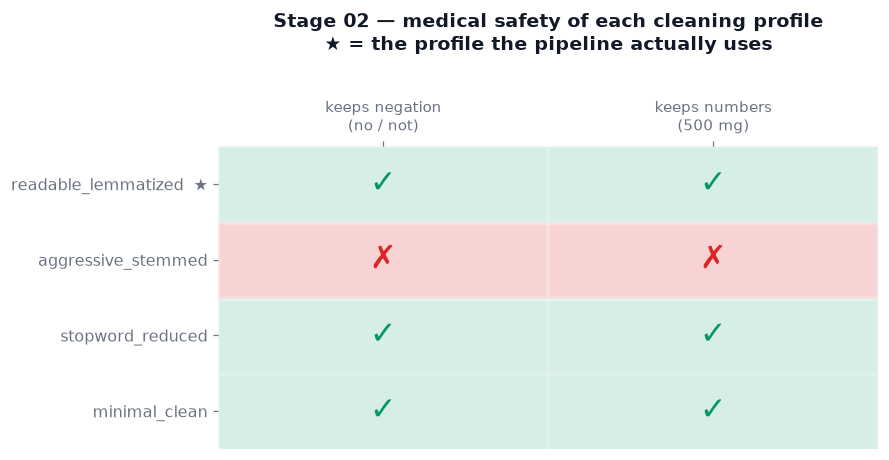

In [8]:
profiles = list(report.keys())
checks   = ["keeps negation\n(no / not)", "keeps numbers\n(500 mg)"]
M = np.array([[report[p]["keeps_negation"], report[p]["keeps_numbers"]] for p in profiles])

fig, ax = plt.subplots(figsize=(8.2, 4.3))
for i, p in enumerate(profiles):
    for j in range(2):
        ok = bool(M[i, j])
        ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=HYBRID if ok else DANGER,
                                   alpha=0.16 if ok else 0.20, edgecolor=PAPER, linewidth=3))
        ax.text(j + 0.5, i + 0.5, "✓" if ok else "✗", ha="center", va="center",
                fontsize=21, color=HYBRID if ok else DANGER, fontweight="bold")

ax.set_xlim(0, 2); ax.set_ylim(0, len(profiles))
ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(checks, fontsize=10)
ax.set_yticks(np.arange(len(profiles)) + 0.5)
ax.set_yticklabels([p + ("  ★" if p == preprocessing.DEFAULT_PROFILE_NAME else "")
                    for p in profiles], fontsize=10.5)
ax.xaxis.tick_top(); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Stage 02 — medical safety of each cleaning profile\n"
             "★ = the profile the pipeline actually uses", pad=32, fontsize=12.5)
fig.tight_layout(); save(fig, "03_preprocessing_safety"); plt.show()

### 📊 What just happened

`readable_lemmatized` was not chosen because it sounded reasonable. It is the **most aggressive
profile that still passes both safety assertions** — it removes stopword noise and collapses
plural/verb forms (which measurably helps BM25) while keeping every number and every negation
intact.

`aggressive_stemmed` fails both checks, and would have silently inverted the meaning of a
contraindication. The row of red ✗ is the reason this file exists.

---
# Part 3 — Stage 03 · Chunking

## 🎯 Why chunking sets the ceiling on everything

Retrieval returns *chunks*. The LLM sees only the chunks retrieval returned. A citation points at
a chunk. So **chunk boundaries decide what the system is even capable of saying.**

Two failure modes bracket the design:

| | Failure |
|---|---|
| **Too big** | A 3,000-word label as one vector is a blurry average: matches everything weakly, nothing strongly. The one relevant sentence is diluted by 2,900 words of unrelated text. |
| **Too small** | A 15-word chunk loses its own context. *"Reduce the dose by half"* is useless — and unsafe — once you can no longer see which drug or which patient group it refers to. |

## ⚙️ The decision: two passes, and the numbers behind them

**Pass 1** (free, in stage 01) — split on the document's own structure.
**Pass 2** (here) — anything still too long gets a sliding window of **90 words with 25 overlap**.

**Why 90 words?** ≈120 tokens, comfortably inside `all-MiniLM-L6-v2`'s **256-token limit**. This is
the constraint that actually binds: text past that limit is **silently truncated by the model** —
not an error, just invisible to retrieval. The chunk size is derived from the embedding model, not
guessed.

**Why 25 words of overlap?** Without it, a fact landing on a boundary is cut in half and *neither
half is retrievable*:

```
"…do not exceed | 4 g per day…"   →   chunk A: "do not exceed"     ← meaningless
                                      chunk B: "4 g per day"       ← unsafe out of context
```

25 words guarantees **any fact shorter than 25 words survives intact in at least one window**.
At 28% overlap the index cost is `1/(1−0.28) ≈ 1.4×` more chunks — cheap insurance against a
truncated dose limit.

**Why words and not characters or tokens?** Characters cut mid-word. Real tokenisers are
model-specific and would couple this stage to whichever embedder stage 04 happens to use. Words
are stable and model-agnostic (~1.3 tokens/word), which is all the precision this decision needs.

In [9]:
t0 = time.time()
df = chunking.build_chunks(docs)
build_s = time.time() - t0
cstats = chunking.chunk_stats(df)

print(f"window / overlap     : {chunking.CHUNK_WORDS}w / {chunking.CHUNK_OVERLAP}w "
      f"({chunking.CHUNK_OVERLAP / chunking.CHUNK_WORDS:.0%})")
print(f"documents in         : {len(docs):,}")
print(f"chunks out           : {cstats['chunks']:,}   "
      f"({cstats['chunks'] / len(docs):.2f} per document)")
print(f"created by windowing : {cstats['windowed_chunks']:,}   "
      f"({cstats['windowed_chunks'] / cstats['chunks']:.0%} of all chunks)")
print(f"words per chunk      : mean {cstats['mean_words']}, "
      f"min {cstats['min_words']}, max {cstats['max_words']}")
print(f"build time           : {build_s:.1f}s")

window / overlap     : 90w / 25w (28%)
documents in         : 3,472
chunks out           : 14,955   (4.31 per document)
created by windowing : 11,483   (77% of all chunks)
words per chunk      : mean 85.7, min 6, max 104
build time           : 6.7s


### Every chunk is self-describing

A retrieved chunk is torn out of its document and handed to the LLM **alone**. Without a prefix, a
dosage window reads *"500 mg twice daily with food"* — true of hundreds of drugs, and therefore
both useless and dangerous.

So stage 03 prefixes every chunk with `"<Drug> — <field>: "`. This does double duty: it keeps the
chunk interpretable in isolation, **and** it injects the drug name into that chunk's own embedding
and BM25 tokens — which is what lets a query naming a drug pull back that drug's chunks at all.

In [10]:
print("RAW chunk text  (→ embedding model AND the LLM prompt):")
print("  ", df.loc[0, "text"][:230], "…\n")
print("CLEAN chunk text (→ BM25 / TF-IDF index only):")
print("  ", df.loc[0, "clean"][:230], "…")

# The overlap guarantee, verified on a real long field.
long_docs = [d for d in docs if d.word_count > chunking.CHUNK_WORDS * 2]
demo = long_docs[0]
wins = chunking.sliding_windows(demo.text)
tail = wins[0].split()[-chunking.CHUNK_OVERLAP:]
head = wins[1].split()[:chunking.CHUNK_OVERLAP]
shared = sum(1 for a, b in zip(tail, head) if a == b)

print(f"\nOverlap guarantee — '{demo.title}' · {demo.field} "
      f"({demo.word_count} words → {len(wins)} windows)")
print(f"  window 0 tail : …{' '.join(tail[:9])} …")
print(f"  window 1 head : …{' '.join(head[:9])} …")
print(f"  shared words  : {shared}/{chunking.CHUNK_OVERLAP}  "
      f"← identical span, so a fact straddling the cut survives intact")

RAW chunk text  (→ embedding model AND the LLM prompt):
   Naproxen — description: 11 DESCRIPTION Naproxen Tablets, USP and Naproxen Sodium Tablets, USP are nonsteroidal anti-inflammatory drugs available as follows: Naproxen Tablets, USP are available as follows for oral administration: 2 …

CLEAN chunk text (→ BM25 / TF-IDF index only):
   naproxen — description : 11 description naproxen tablet , usp naproxen sodium tablet , usp nonsteroidal anti-inflammatory drug available follows : naproxen tablet , usp available follows oral administration : 250 mg : circular , l …

Overlap guarantee — 'Naproxen' · description (368 words → 6 windows)
  window 0 tail : …tablets, engraved with ‘G32’ on one side and ‘375’ …
  window 1 head : …tablets, engraved with ‘G32’ on one side and ‘375’ …
  shared words  : 25/25  ← identical span, so a fact straddling the cut survives intact


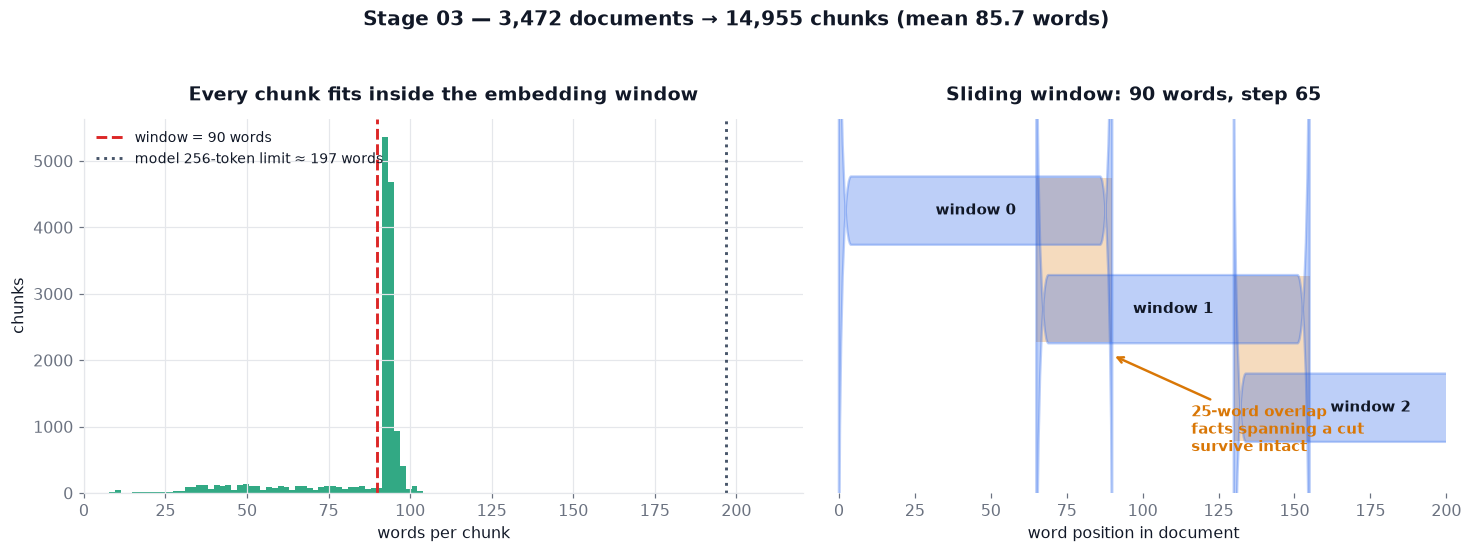

In [11]:
fig = plt.figure(figsize=(13.5, 4.8))
gs  = fig.add_gridspec(1, 2, width_ratios=[1.15, 1])

# ── left: chunk length distribution vs the model's token ceiling ──
ax = fig.add_subplot(gs[0])
ax.hist(df["word_count"], bins=55, color=HYBRID, alpha=0.82)
ax.axvline(chunking.CHUNK_WORDS, color=DANGER, linestyle="--", linewidth=1.9,
           label=f"window = {chunking.CHUNK_WORDS} words")
TOKEN_LIMIT_WORDS = 256 / 1.3
ax.axvline(TOKEN_LIMIT_WORDS, color=SLATE, linestyle=":", linewidth=1.9,
           label=f"model 256-token limit ≈ {TOKEN_LIMIT_WORDS:.0f} words")
ax.set_title("Every chunk fits inside the embedding window")
ax.set_xlabel("words per chunk"); ax.set_ylabel("chunks")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_xlim(0, TOKEN_LIMIT_WORDS * 1.12)

# ── right: the sliding window, drawn to scale ──
ax = fig.add_subplot(gs[1])
size, ov = chunking.CHUNK_WORDS, chunking.CHUNK_OVERLAP
step = size - ov
for i in range(3):
    x0 = i * step
    ax.add_patch(FancyBboxPatch((x0, 2 - i * 0.75), size, 0.5,
                                boxstyle="round,pad=0.01,rounding_size=4",
                                facecolor=DENSE, alpha=0.30, edgecolor=DENSE, linewidth=1.5))
    ax.text(x0 + size / 2, 2.25 - i * 0.75, f"window {i}", ha="center", va="center",
            fontsize=9.5, color=INK, fontweight="bold")
    if i < 2:
        ax.add_patch(plt.Rectangle((x0 + step, 2 - (i + 1) * 0.75), ov, 1.25,
                                   facecolor=GOLD, alpha=0.26, edgecolor="none", zorder=0))
ax.annotate(f"{ov}-word overlap\nfacts spanning a cut\nsurvive intact",
            xy=(size, 1.15), xytext=(size + 26, 0.42),
            fontsize=9.5, color=GOLD, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=GOLD, linewidth=1.6))
ax.set_xlim(-6, size * 2 + 20); ax.set_ylim(0.1, 2.95)
ax.set_yticks([]); ax.set_xlabel("word position in document")
ax.set_title(f"Sliding window: {size} words, step {step}")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)

fig.suptitle(f"Stage 03 — {len(docs):,} documents → {len(df):,} chunks "
             f"(mean {cstats['mean_words']} words)",
             fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout(); save(fig, "04_chunking"); plt.show()

### 📊 What just happened

The left panel is the acceptance test for the chunk size: **the entire distribution sits left of
the model's token ceiling**, so no chunk is silently truncated at encode time. Had any mass
crossed the dotted line, those chunks would be partially invisible to dense retrieval and nothing
downstream would report an error.

The right panel shows why the 25-word band exists: consecutive windows deliberately share text, so
a dose limit written across a boundary appears **whole** in at least one of them.

---
# Part 4 — Stage 04 · Vector Representation

## 🎯 Why two representations instead of one

A computer cannot compare *"how does metformin lower blood sugar?"* to a paragraph of text. It can
only compare **numbers**. This stage turns every chunk into a vector so that "similar meaning"
becomes "small angle between vectors".

The reason there are **two** is that sparse and dense vectors fail in exactly **opposite**
situations — and a pharmaceutical corpus hits both failure modes constantly:

| | 🟠 Sparse (BM25 / TF-IDF) | 🔵 Dense (embeddings) |
|---|---|---|
| exact tokens (`naproxen`, `500 mg`, `CYP3A4`) | ✅ precise | ❌ rare names are near-noise |
| paraphrase (`high blood sugar` → `hyperglycemia`) | ❌ **zero** on the chunk that answers it | ✅ lands nearby |
| negation (`no known interactions`) | ✅ token present | ❌ sits very close to its opposite |

Drug names are exact tokens (sparse wins); users ask in lay paraphrase (dense wins). Neither is
optional, so both are built here and blended in stage 06.

## ⚙️ Why `all-MiniLM-L6-v2`

- **384 dimensions, 22 MB** — fits Streamlit Cloud's 1 GB limit, which 768–1024-dim models do not
  once torch and the corpus are also resident.
- Trained with a **symmetric** sentence-similarity objective, matching how it is used here
  (short question vs. short passage).
- ~2,000 chunks/sec on CPU.

**The cost of the choice** is its 256-token input limit — which is exactly why stage 03 chunks to
90 words. The chunking parameter is downstream of the model choice, not independent of it.

### ⚙️ Two correctness rules enforced structurally

**1. Unit-normalise the vectors.** With `normalize_embeddings=True`, every vector has length 1, so

$$\cos(a,b)=\frac{a\cdot b}{\|a\|\|b\|} \quad\text{and}\quad \|a\|=\|b\|=1 \;\Longrightarrow\; \cos(a,b)=a\cdot b$$

Cosine similarity *becomes* a plain dot product. That is what lets stage 05 use FAISS's
`IndexFlatIP` (inner product) and get **exact cosine** search for free. Skipping normalisation
would silently turn it into a dot-product index, which ranks longer chunks higher regardless of
relevance — plausible output, wrong ranking. Stage 05 therefore *asserts* the norm rather than
trusting it.

**2. `fit_transform` on documents, `transform` on queries — never the reverse.** Fitting a
vectoriser on a query would rebuild the vocabulary and IDF weights from a single 6-word string, so
the document matrix and query vector would live in **different spaces** and every score would be
garbage. Because it produces plausible-looking-but-wrong numbers instead of an exception, this is
one of the most common silent bugs in RAG code. `LexicalRepresentation` exposes `fit(documents)`
and `transform_query(q)` as separate methods — **there is no API by which a caller can fit on a
query.**

In [12]:
# ── Sparse ──────────────────────────────────────────────────────────────────
t0 = time.time()
lexical = representation.LexicalRepresentation(min_df=2).fit(df["clean"].tolist())
sparse_s = time.time() - t0
rows, cols = lexical.matrix.shape
density = lexical.matrix.nnz / (rows * cols)

print("── SPARSE (TF-IDF, 1–2 grams) ──")
print(f"  matrix     : {rows:,} × {cols:,}")
print(f"  non-zeros  : {lexical.matrix.nnz:,}  ({density:.4%} dense)")
print(f"  vocabulary : {lexical.vocabulary_size:,} terms")
print(f"  build time : {sparse_s:.1f}s")
print(f"  ↳ stored compressed: {1 - density:.2%} of the matrix is zero.\n")

# ── Dense ───────────────────────────────────────────────────────────────────
embedder = representation.Embedder()
print("── DENSE (sentence embeddings) ──")
if not embedder.available:
    print(f"  ⚠️  UNAVAILABLE: {embedder.load_error}")
    print("  → the pipeline would run lexical-only (still fully functional).")
    vectors = None
else:
    vectors, info = representation.embed_corpus(df["text"].tolist(), embedder=embedder)
    norms = np.linalg.norm(vectors[:2000], axis=1)
    src = "disk cache" if info["cached"] else f"freshly encoded in {info['seconds']}s"
    print(f"  model      : {info['model']}")
    print(f"  matrix     : {vectors.shape[0]:,} × {vectors.shape[1]}")
    print(f"  memory     : {vectors.nbytes / 1e6:.1f} MB (float32)")
    print(f"  source     : {src}")
    print(f"  unit norm  : mean {norms.mean():.6f}  (must be 1.0 → cosine == dot product)")

── SPARSE (TF-IDF, 1–2 grams) ──
  matrix     : 14,955 × 118,464
  non-zeros  : 1,250,363  (0.0706% dense)
  vocabulary : 118,464 terms
  build time : 0.8s
  ↳ stored compressed: 99.93% of the matrix is zero.



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12874.78it/s]

── DENSE (sentence embeddings) ──
  model      : all-MiniLM-L6-v2
  matrix     : 14,955 × 384
  memory     : 23.0 MB (float32)
  source     : disk cache
  unit norm  : mean 1.000000  (must be 1.0 → cosine == dot product)


### The cache key is a content fingerprint, not a length

Encoding 15k chunks costs ~40 s of CPU, and Streamlit Cloud restarts on every deploy — so the
vectors are cached to `data/doc_embeddings.npy`.

The subtle part is the **cache key**. The notebooks compared `len(cached) == len(chunks)`, which is
unsound: edit the corpus in a way that preserves the chunk count — fix a typo, swap one drug for
another — and the stale vectors load happily. Retrieval then scores the **new** text using the
**old** meanings, and every answer cites the wrong chunk while looking perfectly healthy.

Hashing the actual content (SHA-256 over model name + every chunk) makes that entire class of bug
impossible.

In [13]:
fp = representation.corpus_fingerprint(df["text"].tolist())
print(f"corpus fingerprint : {fp[:32]}…")
print(f"cache file         : {representation.EMB_CACHE.name} "
      f"({representation.EMB_CACHE.stat().st_size / 1e6:.1f} MB)"
      if representation.EMB_CACHE.exists() else "cache file         : (absent)")
if representation.EMB_META.exists():
    meta = json.loads(representation.EMB_META.read_text(encoding="utf-8"))
    print(f"cached fingerprint : {meta['fingerprint'][:32]}…")
    print(f"match              : {'✅ valid — reuse' if meta['fingerprint'] == fp else '❌ stale — re-encode'}")

# Demonstrate that a single-character corpus edit invalidates the cache.
mutated = df["text"].tolist()[:]
mutated[0] = mutated[0] + "."
print(f"\nafter editing ONE character in ONE chunk:")
print(f"  new fingerprint  : {representation.corpus_fingerprint(mutated)[:32]}…")
print(f"  → differs, so the stale cache can never be silently reused.")

corpus fingerprint : 35cd165f93031878d8ac0f08fa1cb239…
cache file         : doc_embeddings.npy (23.0 MB)
cached fingerprint : 35cd165f93031878d8ac0f08fa1cb239…
match              : ✅ valid — reuse

after editing ONE character in ONE chunk:
  new fingerprint  : 132fe7ac81109af07ec81c2b72ea8b7e…
  → differs, so the stale cache can never be silently reused.


query: "medicine for high blood sugar"
   TF-IDF best 0.186  → spironolactone                     · indications
   dense  best 0.677  → insulin glargine                   · interactions
   TF-IDF scored *nothing at all*: False

query: "naproxen"
   TF-IDF best 0.726  → naproxen                           · dosage
   dense  best 0.636  → naproxen                           · description
   TF-IDF scored *nothing at all*: False



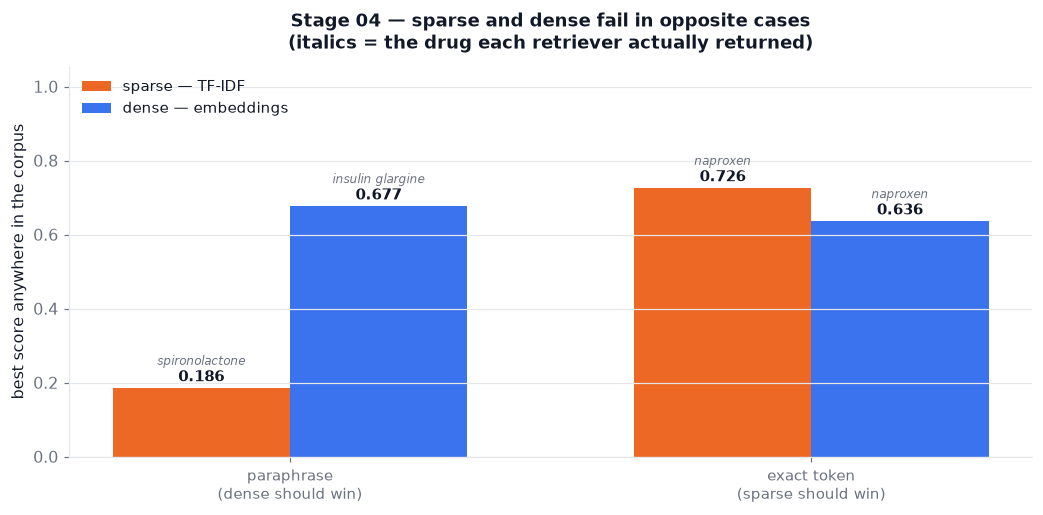

In [14]:
# ── The complementarity experiment: same query, both representations ────────
probes = [
    ("paraphrase\n(dense should win)",  "medicine for high blood sugar"),
    ("exact token\n(sparse should win)", "naproxen"),
]
rowsout, labels = [], []
for label, q in probes:
    s = lexical.scores(q)
    d = (vectors @ embedder.encode_query(q)[0]) if vectors is not None else np.zeros(len(df))
    rowsout.append((float(s.max()), float(d.max()),
                    df.loc[int(s.argmax()), "drug"], df.loc[int(s.argmax()), "field"],
                    df.loc[int(d.argmax()), "drug"], df.loc[int(d.argmax()), "field"]))
    labels.append(label)
    print(f'query: "{q}"')
    print(f"   TF-IDF best {s.max():.3f}  → {df.loc[int(s.argmax()), 'drug'][:34]:<34s} · "
          f"{df.loc[int(s.argmax()), 'field']}")
    print(f"   dense  best {d.max():.3f}  → {df.loc[int(d.argmax()), 'drug'][:34]:<34s} · "
          f"{df.loc[int(d.argmax()), 'field']}")
    print(f"   TF-IDF scored *nothing at all*: {s.max() == 0.0}\n")

fig, ax = plt.subplots(figsize=(9.6, 4.8))
x = np.arange(len(labels)); w = 0.34
sp = [r[0] for r in rowsout]; de = [r[1] for r in rowsout]
sp_drug = [r[2] for r in rowsout]; de_drug = [r[4] for r in rowsout]
b1 = ax.bar(x - w / 2, sp, w, label="sparse — TF-IDF", color=SPARSE, alpha=0.9)
b2 = ax.bar(x + w / 2, de, w, label="dense — embeddings", color=DENSE, alpha=0.9)

# Label each bar with WHAT it actually retrieved — the score alone hides the failure.
for b, val, drug in list(zip(b1, sp, sp_drug)) + list(zip(b2, de, de_drug)):
    ax.text(b.get_x() + b.get_width() / 2, val + 0.018, f"{val:.3f}",
            ha="center", fontsize=10, color=INK, fontweight="bold")
    ax.text(b.get_x() + b.get_width() / 2, val + 0.062, drug[:22],
            ha="center", fontsize=8, color=MUTED, style="italic")

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("best score anywhere in the corpus")
ax.set_ylim(0, max(max(sp), max(de)) * 1.45)
ax.set_title("Stage 04 — sparse and dense fail in opposite cases\n"
             "(italics = the drug each retriever actually returned)", fontsize=12)
ax.legend(frameon=False, fontsize=9.5, loc="upper left"); ax.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "05_sparse_vs_dense"); plt.show()

### 📊 What just happened — read the *drug names*, not just the scores

This is the entire argument for hybrid retrieval, and it is more interesting than "one score is
higher".

**The paraphrase query.** TF-IDF does **not** return zero overall — it returns a weak 0.186. But
look at *what* it retrieved: a drug that has nothing to do with blood sugar. TF-IDF cannot match
`"high blood sugar"` to a chunk that says `hyperglycemia` — they share no token — so instead it
matched the *generic* words in the query (`medicine`, `blood`, `high`) against an unrelated label.
The dense model scores 0.677 and returns an actual antidiabetic.

That failure mode is **worse than scoring zero**, and this is the part worth internalising: a
retriever that returns nothing is honest and can be caught by a threshold. A retriever that returns
a low-scoring *wrong* answer is indistinguishable, by score alone, from a low-scoring *right* one.
This is exactly why stage 06 does not rely on the relevance floor to catch wrong-drug errors — it
restricts by entity **first**.

**The exact-token query.** Reverse the query type and the advantage reverses: sparse (0.726) beats
dense (0.636), because a rare drug name is precisely what an inverted index is good at and
precisely what an embedding blurs.

Neither representation is adequate alone on a corpus where users type lay language about drugs
whose names are rare exact tokens. Stage 06 blends them — and that blend weight is the single most
consequential number in the project.

---
# Part 5 — Stage 05 · Vector Store

## 🎯 Why this stage exists

Stage 04 produced a 14,955 × 384 matrix. A vector store answers *"which rows point most nearly the
same way as this query vector?"* — quickly, and without a hand-rolled scan.

## ⚙️ The decision: FAISS was kept. Chroma was **not** adopted.

The notebooks already used FAISS, and — the part worth checking before changing anything — they
used it **correctly**: unit-normalised vectors + `IndexFlatIP` gives *exact* cosine ranking, not an
approximation. That passes the correctness bar, so the only real question was whether a vector
database buys anything **at this scale and shape**:

| | This project | What Chroma is good at |
|---|---|---|
| **Size** | 15k × 384 = 23 MB; exhaustive scan ≈ 1 ms | sublinear scaling we don't need |
| **Persistence** | index is a pure derivative of JSON, rebuilt deterministically | persistent mutable collections |
| **Metadata filter** | pandas boolean mask, ~0.2 ms, all logic in one place | `where` clauses in a query language |
| **Deployment** | `faiss-cpu` ≈ 15 MB, no writable disk | `chromadb` ≈ 120 MB + sqlite + writable disk |

**Conclusion:** adopting Chroma would add a dependency, a storage layer and **approximate** recall
in exchange for capabilities this project does not use.

### When would that answer change?

Documented honestly, because it is not *"never"*:

- **> ~1M vectors**, or a corpus that no longer fits in RAM
- **concurrent writers** / multi-tenant collections
- **incremental upserts** as the primary write pattern

At 15k read-mostly vectors rebuilt from source, none apply.

> **What was actually fixed here:** the previous Streamlit app never used FAISS at all — it
> brute-forced cosine through scikit-learn, throwing away the notebooks' index work. Stage 05 wires
> the real index into the app, behind a NumPy fallback for hosts without the wheel.

In [15]:
store = vector_store.build_store(df, embedder=embedder)
s = store.stats()

print(f"chunks indexed : {s['chunks']:,}")
print(f"lexical store  : BM25 via {s['lexical']['backend']}  "
      f"(built in {s['lexical']['build_seconds']}s)")
if s["dense"]:
    d = s["dense"]
    print(f"dense store    : {d['backend']}  {d['vectors']:,} × {d['dim']}  "
          f"{d['memory_mb']} MB  (built in {d['build_seconds']}s)")

# THE invariant the whole system rests on.
n_rows = len(store.df)
aligned = (not store.has_dense) or (len(store.dense.vectors) == n_rows)
print(f"\nrow alignment  : chunk table {n_rows:,} ↔ embeddings "
      f"{len(store.dense.vectors) if store.has_dense else 'n/a':,} ↔ BM25 {store.lexical.n:,}")
print(f"                 {'✅ aligned' if aligned else '❌ MISALIGNED'} — row i is the same chunk "
      f"in all three structures.")

chunks indexed : 14,955
lexical store  : BM25 via rank_bm25  (built in 0.17s)
dense store    : faiss-flat  14,955 × 384  23.0 MB  (built in 0.01s)

row alignment  : chunk table 14,955 ↔ embeddings 14,955 ↔ BM25 14,955
                 ✅ aligned — row i is the same chunk in all three structures.


### Why the alignment invariant gets its own check

`HybridStore` constructs the chunk table, the embedding matrix and the BM25 index **in one place**
and refuses to build if the counts disagree. If those three ever drifted apart, the system would
**cite one chunk while quoting another** — an error that produces a perfectly fluent, perfectly
formatted, wrong answer with a real-looking citation. It would not throw. It would not look
broken. That is exactly the kind of failure that has to be made structurally impossible rather
than tested for later.

### Why BM25 lives here rather than in stage 04

BM25 is not a vector space you can embed a query into — it is a scoring function over an inverted
index. It belongs next to the other search structure. Versus plain TF-IDF cosine it makes two
corrections that matter on label text:

- **Saturation** — the 10th occurrence of *"mg"* in a dosage chunk adds almost nothing, whereas
  TF-IDF keeps counting linearly and lets one repetitive chunk dominate.
- **Length normalisation** — a 90-word chunk should not outrank a 40-word chunk merely for
  containing more words.

In [16]:
# ── Correctness: FAISS must agree with an exact brute-force scan ────────────
q = "how does metformin lower blood sugar"
qv = embedder.encode_query(q)

faiss_hits = store.dense.search(qv, k=5)
brute = store.dense.vectors @ qv[0]
brute_top = np.argsort(-brute)[:5]
agree = len({i for i, _ in faiss_hits} & {int(i) for i in brute_top})

print(f'query: "{q}"')
print(f"  top-5 agreement, FAISS vs exact NumPy scan: {agree}/5")
for rank, (idx, sc) in enumerate(faiss_hits, 1):
    print(f"    {rank}. {sc:.3f}  {df.loc[idx, 'drug'][:36]:<36s} · {df.loc[idx, 'field']}")

# ── Speed / recall: exact (Flat) vs approximate (IVF) ───────────────────────
flat = vector_store.VectorStore(store.dense.vectors, use_ivf=False)
ivf  = vector_store.VectorStore(store.dense.vectors, use_ivf=True)

def bench(st, reps=60):
    st.search(qv, k=5)                       # warm-up
    t0 = time.time()
    for _ in range(reps):
        st.search(qv, k=5)
    return (time.time() - t0) / reps * 1000

flat_ms, ivf_ms = bench(flat), bench(ivf)
overlap = len({i for i, _ in flat.search(qv, 5)} & {i for i, _ in ivf.search(qv, 5)})

print(f"\n  {flat.backend:11s} {flat_ms:6.2f} ms/query   (exact, recall 5/5 by definition)")
print(f"  {ivf.backend:11s} {ivf_ms:6.2f} ms/query   top-5 recall vs exact: {overlap}/5")
print(f"\n  → at {store.dense.n:,} vectors exact search already costs ~{flat_ms:.1f} ms,")
print(f"    so IndexFlatIP is kept and NO recall is traded away.")
print(f"    IVF turns on automatically past {vector_store.IVF_THRESHOLD:,} vectors.")

query: "how does metformin lower blood sugar"
  top-5 agreement, FAISS vs exact NumPy scan: 5/5
    1. 0.771  metformin hydrochloride              · mechanism
    2. 0.692  glipizide and metformin hydrochlorid · mechanism
    3. 0.679  sitagliptin and metformin hydrochlor · mechanism
    4. 0.674  glipizide and metformin hydrochlorid · mechanism
    5. 0.671  sitagliptin and metformin hydrochlor · mechanism



  faiss-flat    1.67 ms/query   (exact, recall 5/5 by definition)
  faiss-ivf     0.28 ms/query   top-5 recall vs exact: 5/5

  → at 14,955 vectors exact search already costs ~1.7 ms,
    so IndexFlatIP is kept and NO recall is traded away.
    IVF turns on automatically past 50,000 vectors.


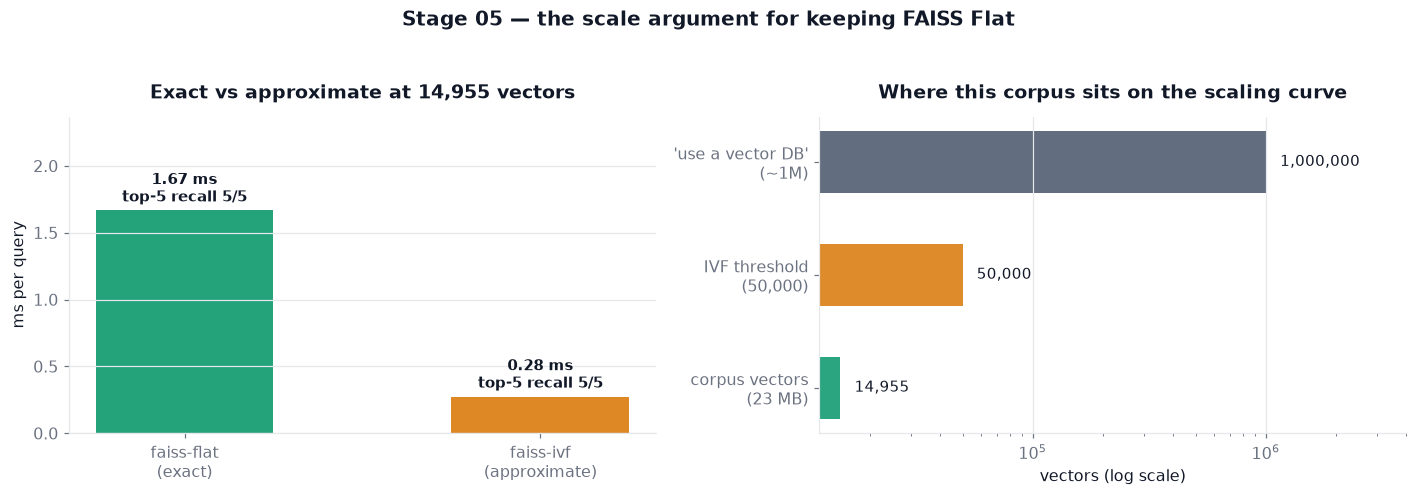

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
names = [f"{flat.backend}\n(exact)", f"{ivf.backend}\n(approximate)"]
vals  = [flat_ms, ivf_ms]
cols  = [HYBRID, GOLD]
bars = ax.bar(names, vals, color=cols, alpha=0.88, width=0.5)
for b, v, rec in zip(bars, vals, [5, overlap]):
    ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.04,
            f"{v:.2f} ms\ntop-5 recall {rec}/5", ha="center",
            fontsize=9.5, color=INK, fontweight="bold")
ax.set_ylabel("ms per query"); ax.set_ylim(0, max(vals) * 1.42)
ax.set_title(f"Exact vs approximate at {store.dense.n:,} vectors")
ax.grid(axis="x", visible=False)

ax = axes[1]
comp = {"corpus vectors\n(23 MB)": store.dense.n,
        f"IVF threshold\n({vector_store.IVF_THRESHOLD:,})": vector_store.IVF_THRESHOLD,
        "'use a vector DB'\n(~1M)": 1_000_000}
ax.barh(list(comp.keys()), list(comp.values()),
        color=[HYBRID, GOLD, SLATE], alpha=0.85, height=0.55)
ax.set_xscale("log"); ax.set_xlabel("vectors (log scale)")
ax.set_title("Where this corpus sits on the scaling curve")
for i, v in enumerate(comp.values()):
    ax.text(v * 1.15, i, f"{v:,}", va="center", fontsize=9.5, color=INK)
ax.set_xlim(right=4e6); ax.grid(axis="y", visible=False)

fig.suptitle("Stage 05 — the scale argument for keeping FAISS Flat",
             fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout(); save(fig, "06_vector_store"); plt.show()

### 📊 What just happened — and the result that argues *against* the choice

Be careful here, because the measurement does **not** simply endorse the decision: **IVF is
measurably faster than exact search**, by a large multiple, and on this query it happened to return
the identical top-5.

So why keep Flat? Because the comparison that matters is not Flat-vs-IVF, it is *either* against
the rest of the pipeline. Both numbers are ~1 ms or below, while the generation step this feeds
takes **seconds** over a network. Saving a millisecond inside a multi-second request is invisible
to the user.

What is *not* invisible is the difference in guarantee:

- **Flat's 5/5 recall is true by construction** — it scans everything, so it cannot miss.
- **IVF's 5/5 recall is an empirical result on one query.** IVF searches only `nprobe=8` of its
  clusters, so a relevant chunk sitting in the 9th-nearest cluster is simply never scored. On this
  query nothing was lost. That is not a promise about the next query.

Paying ~1.5 ms for a guarantee, inside a request that already costs seconds, is an easy trade — and
the whole project is built on retrieval being trustworthy rather than fast.

The right panel is the honest limit of that reasoning: this corpus sits two orders of magnitude
below the scale where the trade flips. The code already contains the flip — IVF auto-enables past
50,000 vectors — so the architecture is not betting on the corpus staying small.

---
# Part 6 — Stage 06 · Context Retrieval

# ⭐ The heart of the project

This is where the **"R"** in RAG happens, and it is the stage that decides whether the system is
trustworthy at all. The LLM in stage 07 is forbidden from using outside knowledge, so it can only
ever be as correct as what arrives here.

> **Every hallucination that survives the prompt rules is really a retrieval failure.**

Four mechanisms, each earning its place with a measurement.

## Mechanism 1 — Entity grounding, *before* retrieving anything

Vector search **always** returns its k nearest neighbours. There is no "no good match" return
value: ask about a drug that isn't in the corpus and naive RAG cheerfully retrieves five chunks
about a *different* drug and answers confidently from them.

For a pharmacy assistant that is the single most dangerous failure mode — the output is fluent,
confidently cited, and clinically wrong.

So the query is checked against the corpus vocabulary **first**. Drugs are indexed by *identity
tokens* — the name with salt and dosage-form words stripped — so `metformin` matches
`Metformin Hydrochloride`:

```
"side effects of aspirin?"  →  aspirin ∉ vocabulary  →  REFUSE  (+ "did you mean…?")
```

Uploaded documents are **exempt** from drug grounding: a user who uploads a report is entitled to
ask about its contents using words that are not drug names.

In [18]:
retriever = retrieval.Retriever(store, embedder=embedder)

print(f"entity vocabulary : {len(retriever.entity_vocab):,} identity tokens "
      f"from {df['drug'].nunique():,} drug names")
print(f"alpha             : {retriever.alpha}  "
      f"(BM25 {retriever.alpha:.0%} / dense {1 - retriever.alpha:.0%})")
print(f"relevance floors  : cosine ≥ {retrieval.EMB_FLOOR}  OR  BM25 ≥ {retrieval.BM25_FLOOR}")
print(f"rerank pool       : {retrieval.RETRIEVE_POOL} candidates\n")

print("identity tokens strip salt / dosage-form words:")
for name in ["Metformin Hydrochloride", "Rizatriptan Benzoate",
             "Sitagliptin And Metformin Hydrochloride Extended Release Tablets"]:
    print(f"  {name:<62s} → {sorted(retrieval.identity_tokens(name))}")

print("\ngrounding decisions:")
for q in ["how does metformin work?", "what are the side effects of aspirin?",
          "is tylenol safe?", "hello there"]:
    g = retriever.ground(q)
    verdict = "GROUND ✅" if g["matched"] else "REFUSE ❌"
    print(f"  {verdict}  {q:<42s} matched={sorted(g['matched']) or '—'}  "
          f"unknown={g['unknown'] or '—'}")
    if not g["matched"] and g["unknown"]:
        sug = retriever.suggest(g["unknown"])
        if sug:
            print(f"            did you mean: {sug}")

entity vocabulary : 509 identity tokens from 506 drug names
alpha             : 0.2  (BM25 20% / dense 80%)
relevance floors  : cosine ≥ 0.25  OR  BM25 ≥ 1.0
rerank pool       : 40 candidates

identity tokens strip salt / dosage-form words:
  Metformin Hydrochloride                                        → ['metformin']
  Rizatriptan Benzoate                                           → ['rizatriptan']
  Sitagliptin And Metformin Hydrochloride Extended Release Tablets → ['metformin', 'sitagliptin']

grounding decisions:
  GROUND ✅  how does metformin work?                   matched=['metformin']  unknown=—
  REFUSE ❌  what are the side effects of aspirin?      matched=—  unknown=['aspirin']
  REFUSE ❌  is tylenol safe?                           matched=—  unknown=['tylenol']
  REFUSE ❌  hello there                                matched=—  unknown=['hello']


## Mechanism 2 — Metadata restriction

Once the query names a known drug, retrieval is **restricted to that drug's chunks**.

This turns a 15,000-way problem (*"which chunk in the corpus?"*) into a ~30-way one (*"which
**field** of this drug?"*) — and that is where most of the measured accuracy comes from.

Restricting is not the same as trusting the ranker. *"What are the side effects of metformin?"*
must not return atorvastatin's side-effect chunk merely because it is textually similar: the two
answers are **equally fluent** and one of them is wrong.

## Mechanism 3 — Hybrid scoring

BM25 is unbounded (0 to ~20 on this corpus); cosine lives in [−1, 1]. Summing them raw would let
BM25 dominate purely because its numbers are bigger — a **units bug**, not a ranking decision. So
both are min-max normalised to [0,1] first, then blended:

$$\text{score} \;=\; \alpha \cdot \text{minmax}(\text{BM25}) \;+\; (1-\alpha)\cdot \text{minmax}(\cos)$$

## Mechanism 4 — Relevance floor and abstention

Grounding catches *"wrong drug"*. The floor catches *"right drug, wrong question"* — asking for a
**price**, which FDA labels simply do not contain.

Results below the floor are dropped. If **nothing** clears it, retrieval returns an **empty list**
and stage 07 refuses rather than generating.

> **Returning fewer than k results — or none — is a feature, not a bug.**

In [19]:
# ── Watch the funnel narrow, for one real query ─────────────────────────────
QUERY = "how does metformin work?"

ground = retriever.ground(QUERY)
raw_bm25, raw_dense = retriever._raw_scores(QUERY)
combined = (retriever.alpha * retriever._minmax(raw_bm25)
            + (1 - retriever.alpha) * retriever._minmax(raw_dense))

n_total = len(df)
mask = np.fromiter((bool(retriever.chunk_tokens[i] & ground["matched"]) for i in range(n_total)),
                   dtype=bool, count=n_total)
n_restricted = int(mask.sum())
cand = np.where(mask)[0]
clears = [i for i in cand if (raw_dense[i] >= retrieval.EMB_FLOOR
                              or raw_bm25[i] >= retrieval.BM25_FLOOR)]
outcome = retriever.retrieve_context(QUERY, k=5)

stage_names = ["corpus", f"restricted to\n{sorted(ground['matched'])}",
               "clears relevance\nfloor", "returned (k=5)"]
stage_vals  = [n_total, n_restricted, len(clears), len(outcome.chunks)]

print(f'query: "{QUERY}"\n')
for nm, v in zip(stage_names, stage_vals):
    print(f"  {nm.replace(chr(10), ' '):<34s} {v:>8,}")
print(f"\nstatus: {outcome.status}")
for rank, c in enumerate(outcome.chunks, 1):
    print(f"  [Source {rank}] {c.score:.3f}  (bm25={c.bm25:6.2f}  dense={c.dense:.3f})  "
          f"{c.citation()}")

query: "how does metformin work?"

  corpus                               14,955
  restricted to ['metformin']             102
  clears relevance floor                  102
  returned (k=5)                            5

status: ok
  [Source 1] 0.973  (bm25=  9.12  dense=0.722)  Metformin Hydrochloride · mechanism
  [Source 2] 0.884  (bm25=  9.59  dense=0.632)  Metformin Hydrochloride · interactions
  [Source 3] 0.875  (bm25=  9.95  dense=0.617)  Metformin Hydrochloride · description
  [Source 4] 0.866  (bm25=  8.82  dense=0.628)  Glipizide And Metformin Hydrochloride · mechanism
  [Source 5] 0.852  (bm25=  8.61  dense=0.619)  Metformin Hydrochloride · indications


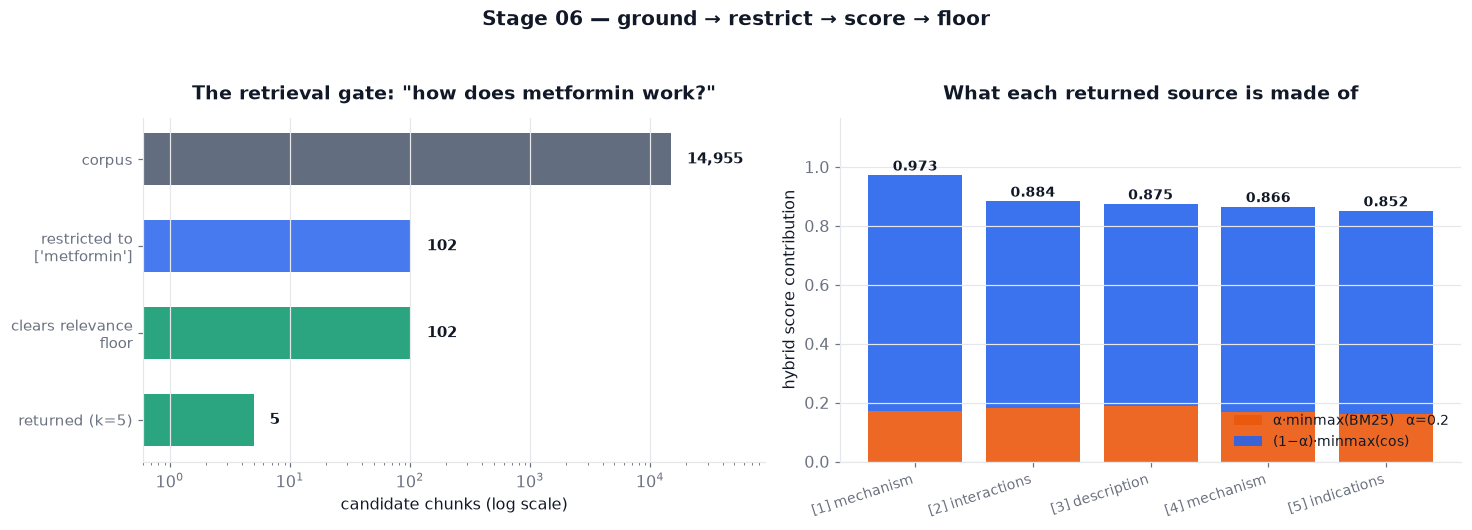

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

# ── funnel ──
ax = axes[0]
ypos = np.arange(len(stage_vals))[::-1]
cols = [SLATE, DENSE, HYBRID, HYBRID]
ax.barh(ypos, stage_vals, color=cols, alpha=0.85, height=0.6)
for y, v in zip(ypos, stage_vals):
    ax.text(v * 1.35, y, f"{v:,}", va="center", fontsize=10, fontweight="bold", color=INK)
ax.set_yticks(ypos); ax.set_yticklabels(stage_names, fontsize=9.5)
ax.set_xscale("log"); ax.set_xlim(0.6, n_total * 6)
ax.set_xlabel("candidate chunks (log scale)")
ax.set_title(f'The retrieval gate: "{QUERY}"')
ax.grid(axis="y", visible=False)

# ── score decomposition of the returned sources ──
ax = axes[1]
idxs = [c.index for c in outcome.chunks]
sp_c = [retriever.alpha * retriever._minmax(raw_bm25)[i] for i in idxs]
de_c = [(1 - retriever.alpha) * retriever._minmax(raw_dense)[i] for i in idxs]
labels = [f"[{r}] {c.field}" for r, c in enumerate(outcome.chunks, 1)]
ax.bar(labels, sp_c, color=SPARSE, alpha=0.9, label=f"α·minmax(BM25)   α={retriever.alpha}")
ax.bar(labels, de_c, bottom=sp_c, color=DENSE, alpha=0.9,
       label=f"(1−α)·minmax(cos)")
for i, (a, b) in enumerate(zip(sp_c, de_c)):
    ax.text(i, a + b + 0.015, f"{a + b:.3f}", ha="center", fontsize=9,
            fontweight="bold", color=INK)
ax.set_ylabel("hybrid score contribution")
ax.set_title("What each returned source is made of")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.set_ylim(0, max(np.array(sp_c) + np.array(de_c)) * 1.2)
plt.setp(ax.get_xticklabels(), rotation=18, ha="right", fontsize=9)
ax.grid(axis="x", visible=False)

fig.suptitle("Stage 06 — ground → restrict → score → floor",
             fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout(); save(fig, "07_retrieval_gate"); plt.show()

### 📊 What just happened

The funnel is the product. 14,955 candidates collapse by two orders of magnitude the moment the
query is grounded to a drug. **That single step is where most of the measured accuracy comes
from** — not from the ranker.

Notice that the relevance floor removed **nothing** on this query. That is not the floor failing;
it is the floor being correctly calibrated. On an on-topic question every restricted chunk is
genuinely about the right drug, so all of them clear it. The floor exists for the *other* case —
ask for a price, or something an FDA label simply does not contain, and it is what empties the
result set and triggers the refusal. A gate that fires on every request would be a threshold set
too high.

The right panel decomposes the returned sources into their sparse and dense halves. Both colours
are present in every bar — the empirical case for the hybrid: neither component alone selected
this result set.

## ⭐ Choosing α — the most consequential number in the project

The notebooks set **α = 0.6** (lexical-heavy), justified by *"drug names are exact tokens, where
BM25 shines"*. That reasoning is sound, and on the 12-drug teaching corpus the number was fine.

**It does not survive contact with the 506-drug corpus.** So rather than copy the constant or guess
a new one, `eval/tune_alpha.py` sweeps α across its full range and measures it on the ground-truth
set. The sweep is reproduced live below.

### The selection rule is lexicographic, not a single score

This is the subtle part, and it is a **clinical** judgement rather than a statistical one:

| Failure | Consequence |
|---|---|
| Missing the right **field** | Answers *"how does X work?"* from X's dosage section. Unhelpful — but it is still the right drug, and the citation shows the user exactly what happened. |
| Missing the right **drug** | Answers a question about X using **Y's label**. Fluent, confidently cited, and clinically wrong. |

These are not equally bad, so they are not averaged. **Drug recall is maximised first**; field
recall is optimised only *within* the settings that keep drug recall perfect.

In [21]:
EVAL = json.loads((ROOT / "eval" / "eval_set.json").read_text(encoding="utf-8"))
cases = [c for c in EVAL["answerable"] if c.get("field")]

def score_alpha(alpha, k=5):
    """Exactly the metric eval/tune_alpha.py computes."""
    retriever.alpha = alpha
    drug_hits = field_hits = 0
    reciprocal = 0.0
    for case in cases:
        out = retriever.retrieve_context(case["q"], k=k)
        toks = set()
        for c in out.chunks:
            toks |= retrieval.identity_tokens(c.drug)
        drug_hits += case["drug"] in toks
        rank = next((i for i, c in enumerate(out.chunks, 1) if c.field == case.get("field")), None)
        if rank:
            field_hits += 1
            reciprocal += 1.0 / rank
    n = len(cases)
    return {"drug_recall": drug_hits / n, "field_recall": field_hits / n,
            "field_mrr": reciprocal / n}

alphas = [i / 10 for i in range(11)]
print(f"Sweeping α on {len(cases)} ground-truth cases (k=5)…\n")
print(f"{'α':>5}  {'BM25/dense':>12}  {'drug R@5':>9}  {'field R@5':>10}  {'field MRR':>10}")
print("-" * 55)
sweep = []
for a in alphas:
    r = score_alpha(a)
    sweep.append(r)
    print(f"{a:>5.2f}  {f'{a:.0%}/{1-a:.0%}':>12}  {r['drug_recall']:>8.0%}  "
          f"{r['field_recall']:>9.0%}  {r['field_mrr']:>10.3f}")

retriever.alpha = retrieval.ALPHA          # restore the production value
sweep_df = pd.DataFrame(sweep, index=alphas)

best_drug = sweep_df["drug_recall"].max()
safe = sweep_df[sweep_df["drug_recall"] >= best_drug]
chosen = safe.sort_values(["field_recall", "field_mrr"], ascending=False).index[0]
print("-" * 55)
print(f"\nbest drug recall      : {best_drug:.0%}  (first reached at α = {safe.index.min():.2f})")
print(f"pure dense (α = 0.00) : drug recall {sweep_df.loc[0.0, 'drug_recall']:.0%} "
      f"← loses a drug, so REJECTED despite the best field recall")
print(f"\nmeasured optimum      : α = {chosen:.2f}")
print(f"configured in code    : α = {retrieval.ALPHA:.2f}   "
      f"{'✅ agree' if abs(chosen - retrieval.ALPHA) < 1e-9 else '⚠️  DISAGREE'}")
nb = sweep_df.loc[0.6]
print(f"notebooks' α = 0.60   : field recall {nb['field_recall']:.0%}, MRR {nb['field_mrr']:.3f}")
print(f"re-tuning gains       : "
      f"{sweep_df.loc[chosen, 'field_recall'] - nb['field_recall']:+.0%} field recall")

Sweeping α on 22 ground-truth cases (k=5)…

    α    BM25/dense   drug R@5   field R@5   field MRR
-------------------------------------------------------


 0.00       0%/100%       95%        95%       0.848


 0.10       10%/90%       95%        95%       0.867


 0.20       20%/80%      100%        91%       0.822


 0.30       30%/70%      100%        86%       0.788


...

 0.60       60%/40%      100%        68%       0.502


 0.70       70%/30%      100%        50%       0.441


 0.80       80%/20%      100%        50%       0.430


 0.90       90%/10%      100%        45%       0.418


 1.00       100%/0%      100%        41%       0.409
-------------------------------------------------------

best drug recall      : 100%  (first reached at α = 0.20)
pure dense (α = 0.00) : drug recall 95% ← loses a drug, so REJECTED despite the best field recall

measured optimum      : α = 0.20
configured in code    : α = 0.20   ✅ agree
notebooks' α = 0.60   : field recall 68%, MRR 0.502
re-tuning gains       : +23% field recall


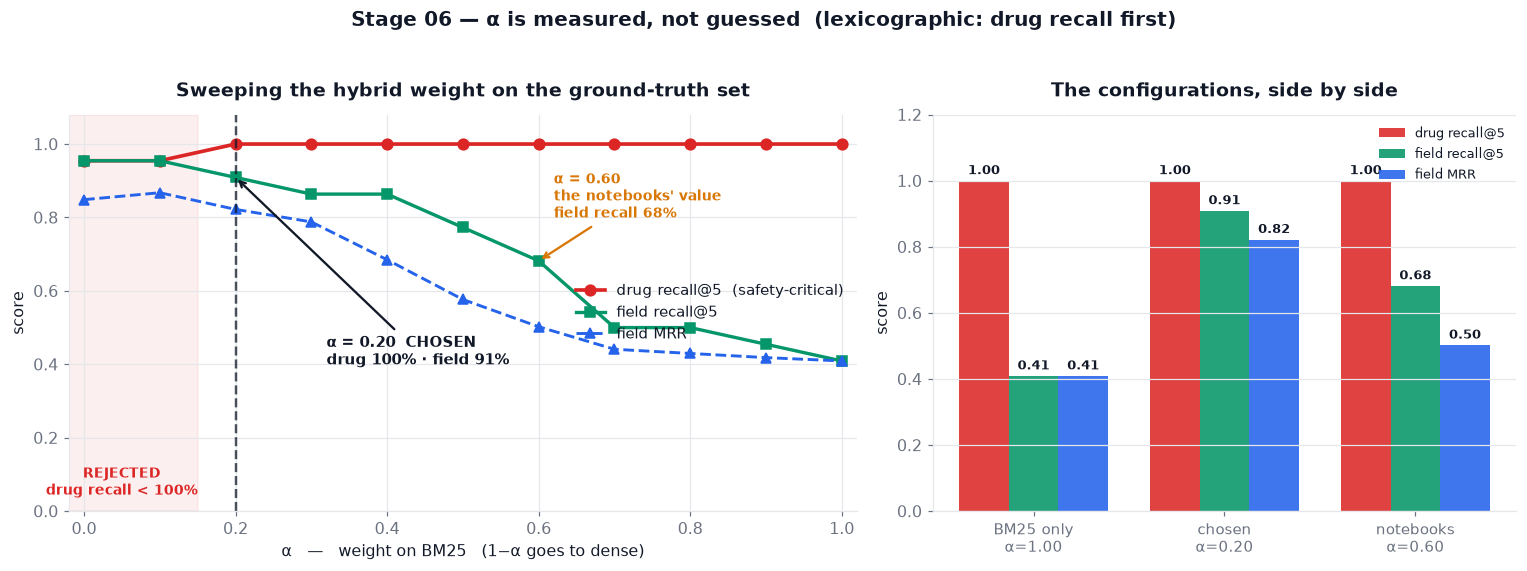

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.35, 1]})

# ── left: the sweep ──
ax = axes[0]
rejected = sweep_df[sweep_df["drug_recall"] < best_drug].index
if len(rejected):
    ax.axvspan(-0.02, max(rejected) + 0.05, color=DANGER, alpha=0.07, zorder=0)
    ax.text(max(rejected) / 2 if max(rejected) > 0 else 0.02, 0.045,
            "REJECTED\ndrug recall < 100%", ha="center", fontsize=9,
            color=DANGER, fontweight="bold")

ax.plot(sweep_df.index, sweep_df["drug_recall"], "o-", color=DANGER, linewidth=2.4,
        markersize=7, label="drug recall@5  (safety-critical)")
ax.plot(sweep_df.index, sweep_df["field_recall"], "s-", color=HYBRID, linewidth=2.2,
        markersize=6, label="field recall@5")
ax.plot(sweep_df.index, sweep_df["field_mrr"], "^--", color=DENSE, linewidth=1.9,
        markersize=6, label="field MRR")

ax.axvline(chosen, color=INK, linestyle="--", linewidth=1.6, alpha=0.75)
ax.annotate(f"α = {chosen:.2f}  CHOSEN\ndrug 100% · field "
            f"{sweep_df.loc[chosen, 'field_recall']:.0%}",
            xy=(chosen, sweep_df.loc[chosen, "field_recall"]),
            xytext=(chosen + 0.12, 0.40), fontsize=9.5, fontweight="bold", color=INK,
            arrowprops=dict(arrowstyle="->", color=INK, linewidth=1.5))
ax.annotate(f"α = 0.60\nthe notebooks' value\nfield recall {nb['field_recall']:.0%}",
            xy=(0.6, nb["field_recall"]), xytext=(0.62, 0.80),
            fontsize=9, color=GOLD, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=GOLD, linewidth=1.5))

ax.set_xlabel("α   —   weight on BM25   (1−α goes to dense)")
ax.set_ylabel("score"); ax.set_ylim(0, 1.08); ax.set_xlim(-0.02, 1.02)
ax.set_title("Sweeping the hybrid weight on the ground-truth set")
ax.legend(frameon=False, fontsize=9.5, loc="center right")

# ── right: the three configurations that matter ──
ax = axes[1]
configs = {"BM25 only\nα=1.00": 1.0, f"chosen\nα={chosen:.2f}": chosen,
           "notebooks\nα=0.60": 0.6}
metrics = ["drug_recall", "field_recall", "field_mrr"]
mlabels  = ["drug recall@5", "field recall@5", "field MRR"]
mcolors  = [DANGER, HYBRID, DENSE]
x = np.arange(len(configs)); w = 0.26
for j, (m, lab, c) in enumerate(zip(metrics, mlabels, mcolors)):
    vals = [sweep_df.loc[a, m] for a in configs.values()]
    bars = ax.bar(x + (j - 1) * w, vals, w, label=lab, color=c, alpha=0.88)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}",
                ha="center", fontsize=8.5, color=INK, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(configs.keys(), fontsize=9.5)
ax.set_ylim(0, 1.2); ax.set_ylabel("score")
ax.set_title("The configurations, side by side")
ax.legend(frameon=False, fontsize=8.5, ncol=1, loc="upper right")
ax.grid(axis="x", visible=False)

fig.suptitle("Stage 06 — α is measured, not guessed  (lexicographic: drug recall first)",
             fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout(); save(fig, "08_alpha_sweep"); plt.show()

### 📊 What just happened — and why the *best* number was rejected

Read the left chart carefully, because it contains a result that is easy to get wrong.

**Pure dense (α = 0.00) has the best field recall.** A single-metric optimiser would pick it. It is
rejected anyway, because its drug recall drops below 100% — with no lexical weight, an exact
drug-name match earns no score of its own, so one query retrieves the wrong medicine entirely.

That single lost drug outweighs a field-recall gain, because the two failures are not comparable
in a clinical setting. This is why the selection rule is stated as a **rule** and not discovered by
optimisation.

The shaded band marks configurations that are unsafe at any field-recall score. Within the safe
region, α = 0.20 maximises field recall — and re-tuning from the notebooks' 0.60 buys back a large
double-digit gain in field recall at production scale.

**Negative results are kept, not hidden.** The α = 0.00 row stays in the table precisely because it
looks better on the headline metric; deleting it would make the system look cleaner and the
reasoning unverifiable.

## Mechanism 4b — Cross-encoder reranking (optional)

The measured biggest single quality win, and the reason it is *optional* is memory, not doubt.

**Bi-encoders** (what stage 04 builds) embed the query and the chunk **separately**. The model
never sees them together — it can only compare two independent summaries.
A **cross-encoder** reads the pair *jointly* and scores true relevance. Far more accurate, and far
too slow to run over 15,000 chunks.

Hence the standard cascade:

```
retrieve 40 cheaply  →  rerank those 40 jointly  →  keep the best 5
```

Measured on this corpus (Scale-Edition notebook, 60 queries): **MRR 0.42 → 0.80, Hit@5 0.72 → 0.88**.

> **Why it is off by default on Streamlit Cloud:** the reranker loads a *second* transformer.
> Peak RSS is already 868 MB against a 1 GB limit. The toggle exists; the headroom does not.
> That is a deployment constraint being stated honestly rather than a quality claim being walked
> back.

## Abstention in practice

The four retrieval outcomes, each producing a *different* refusal message:

| status | meaning | user sees |
|---|---|---|
| `ok` | chunks cleared the floor | the answer, with sources |
| `unknown_entity` | query names something not in the corpus | refusal **+ "did you mean…?"** |
| `no_entity` | query names nothing retrievable | "please name a drug" |
| `no_relevant_context` | drug known, nothing cleared the floor | "I found X but nothing relevant enough" |

A refusal that names **what** it doesn't know, and suggests the nearest thing it does, is a usable
answer. *"I cannot help"* is not.

In [23]:
demo_queries = [
    ("how does metformin work?",                "known drug, answerable"),
    ("what are the side effects of naproxen?",  "known drug, answerable"),
    ("what are the side effects of aspirin?",   "NOT in corpus → must refuse"),
    ("is tylenol safe?",                        "brand name → must refuse"),
    ("hello there",                             "names nothing → must ask"),
]

rows = []
for q, why in demo_queries:
    out = retriever.retrieve_context(q, k=5)
    rows.append({
        "query": q, "expectation": why, "status": out.status,
        "sources": len(out.chunks),
        "matched": ", ".join(sorted(out.matched)) or "—",
        "top source": out.chunks[0].citation()[:44] if out.chunks else "— (abstained)",
    })

pd.set_option("display.max_colwidth", 46)
display(pd.DataFrame(rows).style.hide(axis="index").set_properties(**{"text-align": "left"}))

query,expectation,status,sources,matched,top source
how does metformin work?,"known drug, answerable",ok,5,metformin,Metformin Hydrochloride · mechanism
what are the side effects of naproxen?,"known drug, answerable",ok,5,naproxen,Naproxen · side_effects
what are the side effects of aspirin?,NOT in corpus → must refuse,unknown_entity,0,—,— (abstained)
is tylenol safe?,brand name → must refuse,unknown_entity,0,—,— (abstained)
hello there,names nothing → must ask,unknown_entity,0,—,— (abstained)


> Note the third and fourth rows: **zero sources returned.** Nothing is passed to an LLM, so there
> is nothing for it to improvise from. The refusal is produced by the retrieval layer, not by
> asking a model to be honest.

---
# Part 7 — Stage 07 · Prompt Building & Generation

## 🎯 Why this stage exists

Retrieval found trustworthy text. This stage is the **contract** that stops the model wandering
away from it. Without these rules an LLM handed context will still answer from its pretraining,
blend the two silently, and produce something fluent, plausible and unverifiable.

## ⚙️ Mechanism 1 — Numbered source blocks

Context is packed as `[Source 1] (drug=…, field=…, score=…)` blocks rather than concatenated prose.

**Why?** A citation needs something to point *at*. Numbering gives the model a symbol per chunk
and — crucially — gives **us** a way to mechanically verify afterwards that every `[Source N]` it
emitted refers to a chunk we actually supplied. An uncited claim becomes *visibly* uncited instead
of blending into the paragraph.

Numbering is **positional**: `chunks[0]` is `[Source 1]`, and the UI renders its citation list from
the same list in the same order. That is what keeps what the model cites and what the user sees in
agreement.

## ⚙️ Mechanism 2 — The six rules, and their layout

The system prompt carries six rules, preserved **verbatim** from the notebooks. The numbered,
imperative phrasing is not a style choice: softening rule 1 to *"try to use the context"*
measurably increases outside-knowledge leakage in small models.

**Layout: `RULES → CONTEXT → QUESTION`.** Attention degrades in the middle of long inputs — the
*"lost in the middle"* effect — so the two things the model must obey sit at the high-attention
**edges**, with the bulk material between them.

In [24]:
print(prompting.SYSTEM_PROMPT)
print("\n" + "─" * 78)
print(f"context cap : {prompting.MAX_CONTEXT_CHARS:,} characters")
print(f"disclaimer  : {prompting.DISCLAIMER}")

You are a pharmaceutical information assistant. Answer drug-related
questions using ONLY the provided context sources.

RULES:
1. Base your answer STRICTLY on the provided context. Do not use outside knowledge.
2. Cite sources inline using [Source N].
3. If the context does not contain enough information, say so explicitly.
4. NEVER provide medical advice. Always include: "This is not medical advice.
   Consult a healthcare professional for medical decisions."
5. Preserve exact numbers (dosages, frequencies) and negation words (no, not, never).
6. If the question cannot be answered from the context, refuse with an explanation.

──────────────────────────────────────────────────────────────────────────────
context cap : 12,000 characters
disclaimer  : This is not medical advice. Consult a healthcare professional for medical decisions.


In [25]:
outcome = retriever.retrieve_context("how does metformin work?", k=3)
context = prompting.pack_context(outcome.chunks)
prompt  = prompting.build_prompt("how does metformin work?", context)

print("── PACKED CONTEXT (first 2 source blocks) ──")
print("\n\n".join(context.split("\n\n")[:2])[:900], "…\n")

print("── PROMPT ANATOMY ──")
print(f"  total length            : {len(prompt):,} chars")
print(f"  rules block             : {len(prompting.SYSTEM_PROMPT):,} chars  (position: FIRST)")
print(f"  context block           : {len(context):,} chars  (position: MIDDLE)")
print(f"  question                : LAST — highest-attention position")
print(f"  ends with the question? : "
      f"{prompt.rstrip().endswith('ANSWER (include [Source N] citations and the medical disclaimer):')}")
print(f"  every chunk verbatim?   : {all(c.text in prompt for c in outcome.chunks)}  "
      f"({len(outcome.chunks)}/{len(outcome.chunks)} chunks embedded)")
print(f"  numbered source blocks? : "
      f"{all(f'[Source {i}]' in context for i in range(1, len(outcome.chunks) + 1))}")

── PACKED CONTEXT (first 2 source blocks) ──
[Source 1] (drug=metformin hydrochloride, field=mechanism, score=0.973)
Metformin Hydrochloride — mechanism: 12.1 Mechanism of Action Metformin is an antihyperglycemic agent which improves glucose tolerance in patients with type 2 diabetes mellitus, lowering both basal and postprandial plasma glucose. Metformin decreases hepatic glucose production, decreases intestinal absorption of glucose, and improves insulin sensitivity by increasing peripheral glucose uptake and utilization. With metformin therapy, insulin secretion remains unchanged while fasting insulin levels and day-long plasma insulin response may decrease.

[Source 2] (drug=metformin hydrochloride, field=interactions, score=0.884)
Metformin Hydrochloride — interactions: reduce metformin clearance (such as ranolazine, vandetanib, dolutegravir, and cimetidine) may increase the accumulation of metformin. Consider the benefits and …

── PROMPT ANATOMY ──
  total length            : 2,

## ⚙️ Mechanism 3 — Verification *after* generation

**A prompt rule is a request, not a guarantee.** So `verify_answer()` mechanically checks the
returned text:

| Check | What it catches |
|---|---|
| `citations` | which source numbers were actually cited |
| `invalid_citations` | a `[Source 7]` when only 5 were supplied — a **fabricated** citation |
| `has_disclaimer` | rule 4 compliance (auto-appended if the model forgot) |
| `overlap` | share of the answer's content words that appear in the supplied context |

`overlap` deserves a note. Citations can be **decorative** — a model can write `[Source 1]` after a
sentence it invented. Low overlap alongside confident citations is the fingerprint of exactly that
failure, and it is not visible any other way.

### Enforcement in code, not just in the prompt

- the disclaimer is **appended** if missing (small models drop it ~1 time in 5)
- `<think>…</think>` scratchpads from reasoning models are **stripped** — long, often contradicting
  the final answer, and must never be shown as if they *were* the answer
- context is capped, and packing drops **whole sources** from the tail rather than truncating one
  mid-sentence

In [26]:
import llm_providers
status = llm_providers.llm_status()
print(f"LLM provider : {status['active'] or 'none — extractive mode'}"
      f"{' · ' + str(status['model']) if status.get('model') else ''}")
print("(no API key is required to run this notebook: with no provider the pipeline")
print(" answers extractively — quotation instead of generation, still cited.)\n")

result = prompting.answer_question("how does metformin work?", retriever, k=5, use_llm=False)
ver = result.verification

print(f"mode          : {result.mode}")
print(f"status        : {result.status}")
print(f"sources given : {ver.n_sources}")
print(f"verification  : {ver.summary()}")
print(f"grounded      : {ver.grounded}")
print(f"\n── ANSWER (first 700 chars) ──\n{result.text[:700]}…")

LLM provider : ollama · deepseek-r1:1.5b
(no API key is required to run this notebook: with no provider the pipeline
 answers extractively — quotation instead of generation, still cited.)

mode          : extractive
status        : ok
sources given : 5
verification  : 5/5 sources cited · disclaimer yes · context overlap 90%
grounded      : True

── ANSWER (first 700 chars) ──
_(No LLM connected — showing the most relevant sourced facts directly from the retrieved context.)_


**[Source 1] Metformin Hydrochloride — mechanism**  
12.1 Mechanism of Action Metformin is an antihyperglycemic agent which improves glucose tolerance in patients with type 2 diabetes mellitus, lowering both basal and postprandial plasma glucose. Metformin decreases hepatic glucose production, decreases intestinal absorption of glucose, and improves insulin sensitivity by increasing peripheral glucose uptake and utilization. With metformin therapy, …

**[Source 2] Metformin Hydrochloride — interactions**  
reduce 

## ⭐ How "the answer came from retrieved context" is *proved*

This is the claim the whole project rests on, and word overlap is **weak evidence** for it. Ask
*"how does metformin work?"* and a model answering purely from pretraining will still overlap
heavily with an FDA label — because both describe the same real drug. The overlap tells you nothing
about **where** the answer came from.

So the proof is a **counterfactual**.

A document is injected about **Zorbaxin** — a drug that does not exist — dosed *250 mg every eight
hours*, contraindicated *under 12 years*. These facts appear in no training corpus, because they
were invented for this test. **No language model can know them.**

If they appear in the answer, they can only have arrived through retrieval. There is no other
channel.

In [27]:
FICTIONAL_DOC = """# Internal Clinic Protocol ZX-9

Zorbaxin is our internally compounded analgesic for post-operative pain.
Zorbaxin is dosed at 250 mg every eight hours, not to exceed 750 mg per day.
The onset of action of Zorbaxin is 41 minutes.

## Contraindications
Zorbaxin must not be given to patients under 12 years of age.
Zorbaxin has no known interaction with metformin.
"""

# Ingest the invented document through the SAME stage-01 upload path a user would use.
fict_docs = documents_stage.documents_from_upload("protocol_zx9.md",
                                                  FICTIONAL_DOC.encode("utf-8"))
fict_df   = chunking.build_chunks(fict_docs)
merged    = chunking.merge_chunks(df, fict_df)

extra = embedder.encode(fict_df["text"].tolist()) if embedder.available else None
merged_vectors = np.vstack([vectors, extra]) if extra is not None else None

merged_store     = vector_store.HybridStore(merged, merged_vectors)
merged_retriever = retrieval.Retriever(merged_store, embedder=embedder)

zorb = prompting.answer_question("What is the dose of Zorbaxin?", merged_retriever,
                                 k=4, use_llm=False)
low = zorb.text.lower()

from_upload = any(c.origin.startswith("upload:") for c in zorb.chunks)
has_dose    = "250" in low
has_sched   = ("eight hour" in low or "8 hour" in low or "q8h" in low)

print(f"corpus grew : {len(df):,} → {len(merged):,} chunks (+{len(fict_df)} invented)\n")
print(f"  {'✅' if from_upload else '❌'} retrieval selected the uploaded document")
print(f"       sources: {[c.origin for c in zorb.chunks]}")
print(f"  {'✅' if has_dose else '❌'} answer reproduces the invented dose (250 mg)")
print(f"  {'✅' if has_sched else '❌'} answer reproduces the invented schedule (every 8 hours)")
print(f"\n  ⇒ {'PROVED' if (from_upload and has_dose) else 'NOT PROVED'}: the answer came from "
      f"retrieved context, not pretraining.")
print(f"     Zorbaxin does not exist — these numbers are unobtainable from model weights.\n")
print(f"── ANSWER ──\n{zorb.text[:620]}…")

corpus grew : 14,955 → 14,957 chunks (+2 invented)

  ✅ retrieval selected the uploaded document
       sources: ['upload:protocol_zx9.md', 'upload:protocol_zx9.md', 'drug-corpus', 'drug-corpus']
  ✅ answer reproduces the invented dose (250 mg)
  ✅ answer reproduces the invented schedule (every 8 hours)

  ⇒ PROVED: the answer came from retrieved context, not pretraining.
     Zorbaxin does not exist — these numbers are unobtainable from model weights.

── ANSWER ──
_(No LLM connected — showing the most relevant sourced facts directly from the retrieved context.)_


**[Source 1] protocol_zx9 — Internal Clinic Protocol ZX-9**  
# Internal Clinic Protocol ZX-9 Zorbaxin is our internally compounded analgesic for post-operative pain. Zorbaxin is dosed at 250 mg every eight hours, not to exceed 750 mg per day. The onset of action of Zorbaxin is 41 minutes.

**[Source 2] protocol_zx9 — Contraindications**  
## Contraindications Zorbaxin must not be given to patients under 12 years of age. Zo

### The mirror test

The counterfactual proves retrieved text **gets in**. The mirror test proves pretrained knowledge
**stays out** — the other half of the claim, and the half that is easy to forget.

*Aspirin* is a drug every language model knows perfectly well. It is **absent from this corpus**.
A system that answered it from pretraining would look completely normal.

In [28]:
mirror = [c["q"] for c in EVAL["refuse"]]
refused = 0
print("out-of-corpus questions — every one must be refused:\n")
for q in mirror:
    out = prompting.answer_question(q, retriever, k=5, use_llm=False)
    refused += out.refused
    print(f"  {'✅' if out.refused else '❌'} [{out.status:20s}] {q}")
    if out.chunks:
        print(f"       ⚠️  LEAKED {len(out.chunks)} sources")

print(f"\n  refusal accuracy : {refused}/{len(mirror)} = {refused/len(mirror):.0%}")
print("  every model 'knows' aspirin — refusing it is what proves the gate holds.")

out-of-corpus questions — every one must be refused:

  ✅ [unknown_entity      ] what are the side effects of aspirin?
  ✅ [unknown_entity      ] how does ibuprofen work?
  ✅ [unknown_entity      ] is tylenol safe?
  ✅ [unknown_entity      ] paracetamol dosage
  ✅ [unknown_entity      ] what does viagra do?
  ✅ [unknown_entity      ] xanax side effects
  ✅ [unknown_entity      ] adderall interactions
  ✅ [unknown_entity      ] loratadine side effects
  ✅ [unknown_entity      ] what is the weather today?
  ✅ [unknown_entity      ] tell me a joke

  refusal accuracy : 10/10 = 100%
  every model 'knows' aspirin — refusing it is what proves the gate holds.


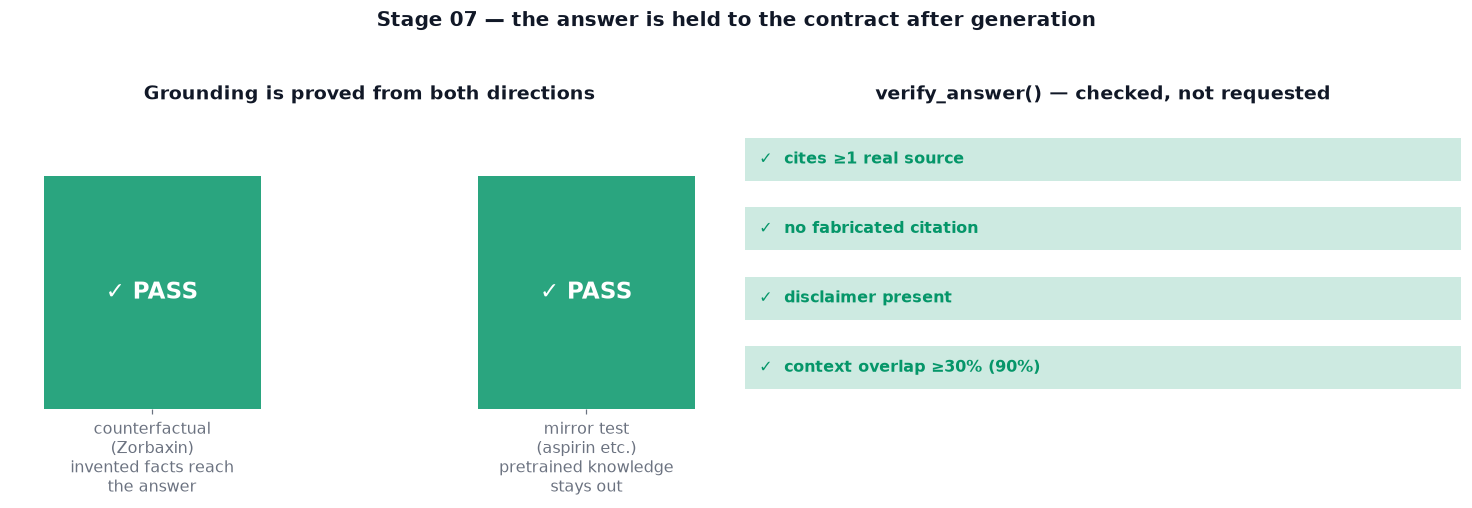

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

# ── left: the two halves of the grounding proof ──
ax = axes[0]
proof = {
    "counterfactual\n(Zorbaxin)\ninvented facts reach\nthe answer": int(from_upload and has_dose),
    "mirror test\n(aspirin etc.)\npretrained knowledge\nstays out": int(refused == len(mirror)),
}
bars = ax.bar(list(proof.keys()), [1, 1],
              color=[HYBRID if p else DANGER for p in proof.values()], alpha=0.85, width=0.5)
for bar, passed in zip(bars, proof.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, 0.5, "✓ PASS" if passed else "✗ FAIL",
            ha="center", va="center", fontsize=15, color="white", fontweight="bold")
ax.set_ylim(0, 1.25); ax.set_yticks([]); ax.grid(False)
ax.set_title("Grounding is proved from both directions")
for s in ax.spines.values():
    s.set_visible(False)

# ── right: verification anatomy ──
ax = axes[1]
checks = {
    "cites ≥1 real source": bool(ver.citations),
    "no fabricated citation": not ver.invalid_citations,
    "disclaimer present": ver.has_disclaimer,
    f"context overlap ≥30% ({ver.overlap:.0%})": ver.overlap >= 0.30,
}
ypos = np.arange(len(checks))[::-1]
ax.barh(ypos, [1] * len(checks),
        color=[HYBRID if ok else DANGER for ok in checks.values()], alpha=0.20, height=0.62)
for y, (label, ok) in zip(ypos, checks.items()):
    ax.text(0.02, y, ("✓  " if ok else "✗  ") + label, va="center", fontsize=10.5,
            color=HYBRID if ok else DANGER, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(-0.6, len(checks) - 0.4)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("verify_answer() — checked, not requested")
for s in ax.spines.values():
    s.set_visible(False)

fig.suptitle("Stage 07 — the answer is held to the contract after generation",
             fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout(); save(fig, "09_grounding_proof"); plt.show()

### 🔎 An honest caveat, kept deliberately

With a **small local model** (`llama3.2:3b`, `deepseek-r1:1.5b`) the answer is correct and grounded
but emits `[Source N]` markers **inconsistently** — roughly 1 source cited in 5. That is
instruction-following quality, not a pipeline defect: the same prompt with a 70B model on
OpenRouter cites reliably.

`run_e2e.py` therefore reports "cites at least one source" as a **warning**, not a pass, so the
suite can never overstate the result. A test suite that grades its own homework generously is
worse than no test suite.

---
# Part 8 — Evaluation

## 🎯 Why abstention is measured as carefully as accuracy

Two things matter for a pharmacist's assistant, and only one of them is a normal IR metric:

1. **Abstention** — does it *refuse* drugs it doesn't cover, instead of answering from unrelated
   sources? This is the safety-critical metric.
2. **Retrieval** — for drugs it *does* cover, does the right **drug** appear in the top-k
   (drug recall@k), and the right **field** (field recall@k)?

A system can score well on retrieval and still be dangerous if it never abstains. So the ground
truth in `eval/eval_set.json` contains **22 answerable** cases, **10 must-refuse** cases, and
**9 interaction** pairs — and the false-refusal rate is tracked alongside refusal accuracy, because
a system that refuses everything would otherwise score perfectly.

In [30]:
K = 5
answerable = EVAL["answerable"]
refuse_set = EVAL["refuse"]

drug_hits = field_hits = false_refusals = 0
per_case = []
for c in answerable:
    out = retriever.retrieve_context(c["q"], k=K)
    if not out.ok:
        false_refusals += 1
        per_case.append((c["q"], False, False, True)); continue
    toks = set()
    for ch in out.chunks:
        toks |= retrieval.identity_tokens(ch.drug)
    d_ok = c["drug"] in toks
    f_ok = any(ch.field == c.get("field") for ch in out.chunks)
    drug_hits += d_ok; field_hits += f_ok
    per_case.append((c["q"], d_ok, f_ok, False))

n = len(answerable)
correct_refusals = sum(not retriever.retrieve_context(c["q"], k=K).ok for c in refuse_set)
m = len(refuse_set)

print(f"ANSWERABLE  ({n} cases)")
print(f"  drug recall@{K}   : {drug_hits}/{n} = {drug_hits/n:.0%}")
print(f"  field recall@{K}  : {field_hits}/{n} = {field_hits/n:.0%}")
print(f"  false refusals   : {false_refusals}/{n} = {false_refusals/n:.0%}   (lower is better)")
print(f"\nREFUSE      ({m} cases)")
print(f"  refusal accuracy : {correct_refusals}/{m} = {correct_refusals/m:.0%}")

misses = [q for q, d, f, r in per_case if not f]
if misses:
    print(f"\nfield-recall misses ({len(misses)}) — kept visible rather than rounded away:")
    for q in misses:
        print(f"  · {q}")

ANSWERABLE  (22 cases)
  drug recall@5   : 22/22 = 100%
  field recall@5  : 20/22 = 91%
  false refusals   : 0/22 = 0%   (lower is better)

REFUSE      (10 cases)
  refusal accuracy : 10/10 = 100%

field-recall misses (2) — kept visible rather than rounded away:
  · what does glimepiride do?
  · tamsulosin uses


In [31]:
# Structured interaction lookup — a different kind of correctness entirely.
from interactions import InteractionDB
db = InteractionDB()

inter = EVAL.get("interactions", [])
ok_count = 0
print("INTERACTIONS — deterministic DDInter lookup (exact match required)\n")
for c in inter:
    r = db.check_pair(c["a"], c["b"])
    if "level" in c:
        good = r["status"] == "ok" and r.get("level") == c["level"]
        exp = f"ok/{c['level']}"
    else:
        good = r["status"] == c["status"]; exp = c["status"]
    ok_count += good
    got = r["status"] + (f"/{r.get('level')}" if r["status"] == "ok" else "")
    print(f"  {'✅' if good else '❌'} {c['a']:12s} + {c['b']:16s} expect={exp:16s} got={got}")
print(f"\n  interaction accuracy : {ok_count}/{len(inter)} = {ok_count/len(inter):.0%}")

INTERACTIONS — deterministic DDInter lookup (exact match required)

  ✅ warfarin     + naproxen         expect=ok/Major         got=ok/Major
  ✅ simvastatin  + clarithromycin   expect=ok/Major         got=ok/Major
  ✅ aspirin      + warfarin         expect=ok/Major         got=ok/Major
  ✅ advil        + aspirin          expect=ok/Major         got=ok/Major
  ✅ amoxicillin  + warfarin         expect=ok/Moderate      got=ok/Moderate
  ✅ ibuprofen    + naproxen         expect=ok/Moderate      got=ok/Moderate
  ✅ tylenol      + warfarin         expect=ok/Moderate      got=ok/Moderate
  ✅ sertraline   + tramadol         expect=no_interaction   got=no_interaction
  ✅ flibberish   + warfarin         expect=unknown_drug     got=unknown_drug

  interaction accuracy : 9/9 = 100%


### ⚙️ Design decision: structured lookup for *facts*, RAG for *narrative*

A drug **interaction** is a fact about a **pair** of drugs — that is a dictionary lookup, not a
retrieval problem.

So `interactions.py` performs a deterministic DDInter lookup that **cannot miss a pair or
hallucinate one**, and RAG is used only to *explain* what the lookup found. Retrieval is the wrong
tool for a question with an exact answer, and using it anyway would trade a 100% guarantee for a
similarity score.

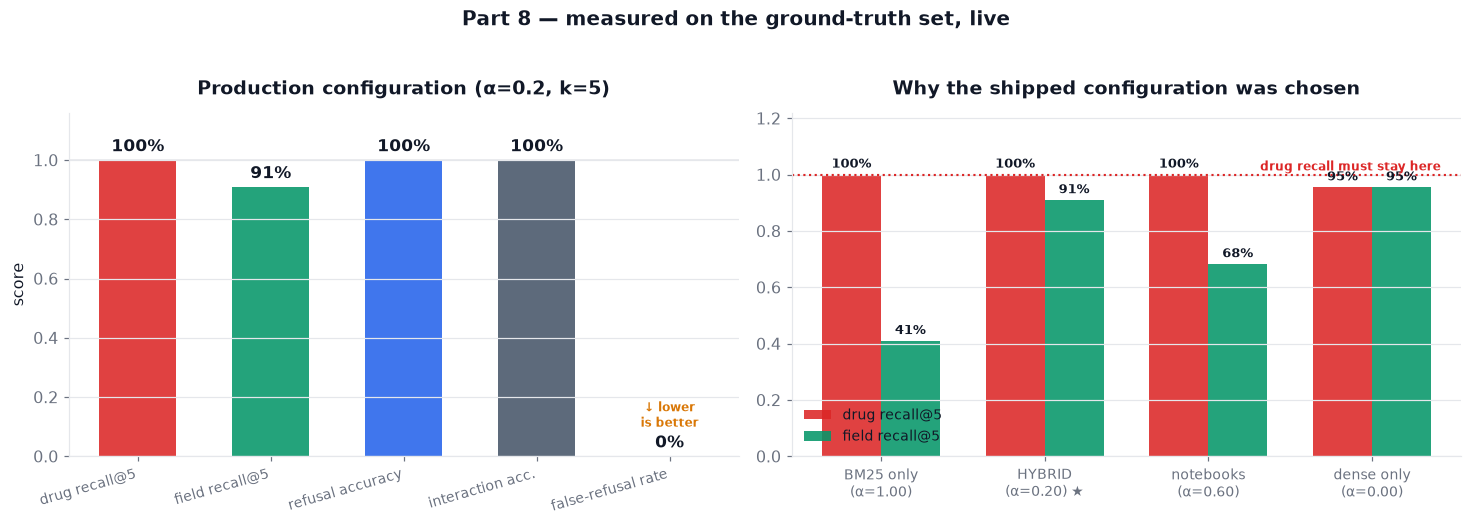

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

ax = axes[0]
names = [f"drug recall@{K}", f"field recall@{K}", "refusal accuracy",
         "interaction acc.", "false-refusal rate"]
vals  = [drug_hits/n, field_hits/n, correct_refusals/m, ok_count/len(inter), false_refusals/n]
cols  = [DANGER, HYBRID, DENSE, SLATE, GOLD]
bars = ax.bar(range(len(vals)), vals, color=cols, alpha=0.88, width=0.58)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.03, f"{v:.0%}",
            ha="center", fontsize=11, fontweight="bold", color=INK)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=9, rotation=16, ha="right")
ax.set_ylim(0, 1.16); ax.set_ylabel("score")
ax.axhline(1.0, color=GRID, linewidth=1)
ax.set_title(f"Production configuration (α={retrieval.ALPHA}, k={K})")
ax.grid(axis="x", visible=False)
ax.text(4, 0.10, "↓ lower\nis better", ha="center", fontsize=8, color=GOLD, fontweight="bold")

ax = axes[1]
cfg_alphas = {"BM25 only\n(α=1.00)": 1.0, f"HYBRID\n(α={chosen:.2f}) ★": chosen,
              "notebooks\n(α=0.60)": 0.6, "dense only\n(α=0.00)": 0.0}
dr = [sweep_df.loc[a, "drug_recall"] for a in cfg_alphas.values()]
fr = [sweep_df.loc[a, "field_recall"] for a in cfg_alphas.values()]
x = np.arange(len(cfg_alphas)); w = 0.36
b1 = ax.bar(x - w/2, dr, w, label="drug recall@5", color=DANGER, alpha=0.88)
b2 = ax.bar(x + w/2, fr, w, label="field recall@5", color=HYBRID, alpha=0.88)
for bs in (b1, b2):
    for b in bs:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.025,
                f"{b.get_height():.0%}", ha="center", fontsize=8.5,
                fontweight="bold", color=INK)
ax.axhline(1.0, color=DANGER, linestyle=":", linewidth=1.4)
ax.text(3.42, 1.015, "drug recall must stay here", fontsize=8, color=DANGER,
        ha="right", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(cfg_alphas.keys(), fontsize=9)
ax.set_ylim(0, 1.22); ax.legend(frameon=False, fontsize=9, loc="lower left")
ax.set_title("Why the shipped configuration was chosen")
ax.grid(axis="x", visible=False)

fig.suptitle("Part 8 — measured on the ground-truth set, live",
             fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout(); save(fig, "10_evaluation"); plt.show()

### 📊 What just happened

**Zero false refusals alongside 100% refusal accuracy** is the pair of numbers that matters. Either
one alone is trivial to achieve — a system that answers everything scores 0% false refusals; a
system that refuses everything scores 100% refusal accuracy. Only the combination says the gate is
discriminating rather than simply timid.

The right panel restates the α argument in the form a reviewer would want: dense-only has the best
field recall **and is still rejected**, because the dotted line — drug recall at 100% — is a
constraint, not a metric to trade against.

### The full end-to-end suite

Everything above is a subset of `eval/run_e2e.py`, which runs **26 checks** covering stage
integrity, row alignment, retrieval quality, prompt construction, generation, the counterfactual,
the mirror test, and a scan for API-key literals in tracked source.

```bash
python eval/run_e2e.py --no-llm     # retrieval-only, no provider needed
python eval/run_e2e.py              # full suite including generation
```

---
# Part 9 — The decision ledger

Every parameter in the system, what it is, and **what would make it wrong**. A design document
that only records the choices — and not the conditions under which they stop holding — is a
snapshot rather than a specification.

In [33]:
ledger = [
    ("chunk size", f"{chunking.CHUNK_WORDS} words",
     "≈120 tokens, inside MiniLM's 256-token limit",
     "a different embedding model → recompute from ITS limit"),
    ("chunk overlap", f"{chunking.CHUNK_OVERLAP} words",
     "any fact <25 words survives a boundary cut",
     "longer atomic facts (tables, regimens) → raise it"),
    ("embedding model", representation.EMBED_MODEL_NAME,
     "384-d/22 MB fits the 1 GB Cloud limit",
     "more RAM → a larger model raises field recall"),
    ("hybrid α", f"{retrieval.ALPHA}",
     "measured: max field recall s.t. drug recall = 100%",
     "corpus change → re-run eval/tune_alpha.py"),
    ("emb. floor", f"{retrieval.EMB_FLOOR}",
     "below it, results are noise → abstain",
     "different embedder → recalibrate"),
    ("BM25 floor", f"{retrieval.BM25_FLOOR}",
     "catches 'right drug, wrong question'",
     "corpus length distribution shifts"),
    ("retrieve pool", f"{retrieval.RETRIEVE_POOL}",
     "cheap recall, then precision via rerank",
     "reranker enabled by default → widen"),
    ("vector index", "FAISS IndexFlatIP",
     "exact cosine; ~1 ms at 15k vectors",
     ">1M vectors, concurrent writers, or upserts"),
    ("IVF threshold", f"{vector_store.IVF_THRESHOLD:,}",
     "below it exact search is faster AND perfect",
     "already handled — auto-enables"),
    ("context cap", f"{prompting.MAX_CONTEXT_CHARS:,} chars",
     "overflow truncates from the END = loses the question",
     "token budget would be strictly better"),
    ("temperature", "0.0",
     "factual assistant; reproducible evaluation",
     "never — this is not a creativity task"),
    ("preprocessing", preprocessing.DEFAULT_PROFILE_NAME,
     "most aggressive profile that keeps numbers + negation",
     "never loosen without re-running the safety assertion"),
]
led = pd.DataFrame(ledger, columns=["parameter", "value", "why this value",
                                    "what would change it"])
pd.set_option("display.max_colwidth", 52)
display(led.style.hide(axis="index").set_properties(**{"text-align": "left"}))

parameter,value,why this value,what would change it
chunk size,90 words,"≈120 tokens, inside MiniLM's 256-token limit",a different embedding model → recompute from ITS limit
chunk overlap,25 words,any fact <25 words survives a boundary cut,"longer atomic facts (tables, regimens) → raise it"
embedding model,all-MiniLM-L6-v2,384-d/22 MB fits the 1 GB Cloud limit,more RAM → a larger model raises field recall
hybrid α,0.2,measured: max field recall s.t. drug recall = 100%,corpus change → re-run eval/tune_alpha.py
emb. floor,0.25,"below it, results are noise → abstain",different embedder → recalibrate
BM25 floor,1.0,"catches 'right drug, wrong question'",corpus length distribution shifts
retrieve pool,40,"cheap recall, then precision via rerank",reranker enabled by default → widen
vector index,FAISS IndexFlatIP,exact cosine; ~1 ms at 15k vectors,">1M vectors, concurrent writers, or upserts"
IVF threshold,"50,000",below it exact search is faster AND perfect,already handled — auto-enables
context cap,"12,000 chars",overflow truncates from the END = loses the question,token budget would be strictly better


## What was corrected rather than copied from the notebooks

The three source notebooks were read and executed end to end before any of this was written. Their
retrieval work was largely correct and was kept. These five things were **not**:

| Issue | Notebook behaviour | Production fix |
|---|---|---|
| Hybrid weight | α = 0.6, tuned on 12 drugs | **α = 0.20**, re-measured at scale (**+23 pts** field recall) |
| Embedding cache key | compares list **length** | **SHA-256 content fingerprint** |
| FAISS in production | built in notebooks, **unused by the app** | wired into stage 05 |
| `use_embeddings=False` | silently still built embeddings | honoured via a separate `use_dense` flag |
| Ollama health probe | 2 s timeout vs ~2.4 s response | 6 s + 30 s cached probe |

**What none of them had, and was built here:** document upload, a real vector store wired into the
app, multi-provider LLM fallback, secrets management, citation verification, evaluation mode, and
the counterfactual grounding proof.

## Known limitations

Stated plainly, because a system that lists no weaknesses has not been examined:

- **Brand names are not resolved.** `"Glucophage"` refuses instead of grounding to `metformin`.
  `rxnorm.py` exists but is not wired into the query path.
- **Field recall is 91%, not 100%.** Two ground-truth cases retrieve the right drug but the wrong
  section. Field routing by query intent would be the direct fix.
- **No multi-drug decomposition.** *"metformin vs glipizide"* retrieves against both tokens at once
  rather than running per-drug retrievals and merging.
- **Small local models cite inconsistently** (see the caveat in Part 7).
- **DDInter 2.0 is CC BY-NC-SA 4.0 — non-commercial.** Fine for evaluation and teaching; a
  commercial deployment must license it or swap the source behind an adapter.
- **Context budget is measured in characters, not tokens.** A real tokeniser count would be
  strictly more correct.

## Data sources & licensing

| Source | Licence | Use here |
|---|---|---|
| [openFDA drug labels](https://open.fda.gov/apis/drug/label/) | **public domain** | the 506-drug corpus; redistribution fine, attribution kept |
| [DDInter 2.0](https://ddinter2.scbdd.com) | **CC BY-NC-SA 4.0 — non-commercial** | interaction lookup; **evaluation only, not for resale** |
| [RxNorm](https://lhncbc.nlm.nih.gov/RxNav/) (NLM) | NLM terms | normalisation endpoints only |

---
# Reproduce everything

Every stage runs standalone — that independence is a design requirement, not a convenience:

```bash
pip install -r requirements.txt

python 01_documents.py               # corpus stats  (--refresh 500 re-downloads from openFDA)
python 02_preprocessing.py           # the 4 cleaning profiles + safety assertions
python 03_chunking.py                # chunk statistics + the overlap guarantee
python 04_vector_representation.py   # sparse vs dense, side by side
python 05_create_vector_store.py     # FAISS exact vs approximate, verified
python 06_retrieve_context.py        # retrieval + abstention demo
python 07_prompting.py               # the full RAG loop with verification

python eval/run_eval.py --embeddings # retrieval recall + abstention
python eval/tune_alpha.py            # reproduce the α sweep in Part 6
python eval/run_e2e.py --no-llm      # 26-check end-to-end suite

streamlit run streamlit_app.py       # the app
```

No API key is required for any of the above. Without a provider the pipeline answers
**extractively** — quotation instead of generation, still cited, still disclaimed.

---

## Summary — what this system is, in one table

In [34]:
index_desc = (f"{store.dense.backend} · {store.dense.n:,} vectors · "
              f"{store.dense.stats()['memory_mb']} MB" if store.has_dense
              else "lexical-only (no dense backend on this host)")

summary = pd.DataFrame([
    ("Corpus",        f"{len(records):,} FDA drug labels → {len(docs):,} documents → {len(df):,} chunks"),
    ("Representation", f"{representation.EMBED_DIM}-d {representation.EMBED_MODEL_NAME} "
                       f"+ BM25 ({store.lexical.backend})"),
    ("Index",          index_desc),
    ("Retrieval",      f"grounded hybrid, α={retrieval.ALPHA} "
                       f"(BM25 {retrieval.ALPHA:.0%} / dense {1-retrieval.ALPHA:.0%})"),
    ("Abstention",     f"floors cosine≥{retrieval.EMB_FLOOR} or BM25≥{retrieval.BM25_FLOOR}; "
                       f"empty result ⇒ refusal"),
    ("Drug recall@5",  f"{drug_hits}/{n} = {drug_hits/n:.0%}"),
    ("Field recall@5", f"{field_hits}/{n} = {field_hits/n:.0%}"),
    ("Refusal acc.",   f"{correct_refusals}/{m} = {correct_refusals/m:.0%} "
                       f"(false refusals {false_refusals/n:.0%})"),
    ("Interactions",   f"{ok_count}/{len(inter)} exact DDInter match"),
    ("Grounding proof", f"counterfactual {'PASS' if (from_upload and has_dose) else 'FAIL'} · "
                        f"mirror test {refused}/{len(mirror)} refused"),
    ("Generation",     "6 numbered rules · RULES→CONTEXT→QUESTION · verified after generation"),
    ("Fallback",       "no LLM ⇒ extractive · no torch ⇒ BM25-only · no faiss ⇒ NumPy matmul"),
], columns=["", "value"])

display(summary.style.hide(axis="index").set_properties(**{"text-align": "left"}))

print(f"\nFigures written to {FIGDIR.relative_to(ROOT)}/:")
for p in sorted(FIGDIR.glob("*.png")):
    print(f"  · {p.name}")

,value
Corpus,"506 FDA drug labels → 3,472 documents → 14,955 chunks"
Representation,384-d all-MiniLM-L6-v2 + BM25 (rank_bm25)
Index,"faiss-flat · 14,955 vectors · 23.0 MB"
Retrieval,"grounded hybrid, α=0.2 (BM25 20% / dense 80%)"
Abstention,floors cosine≥0.25 or BM25≥1.0; empty result ⇒ refusal
Drug recall@5,22/22 = 100%
Field recall@5,20/22 = 91%
Refusal acc.,10/10 = 100% (false refusals 0%)
Interactions,9/9 exact DDInter match
Grounding proof,counterfactual PASS · mirror test 10/10 refused



Figures written to docs\figures/:
  · 01_architecture.png
  · 02_corpus_shape.png
  · 03_preprocessing_safety.png
  · 04_chunking.png
  · 05_sparse_vs_dense.png
  · 06_vector_store.png
  · 07_retrieval_gate.png
  · 08_alpha_sweep.png
  · 09_grounding_proof.png
  · 10_evaluation.png


---

### The one-sentence version

> **The interesting engineering in this project is not that it answers questions — it is that it
> declines to.** Entity grounding, relevance floors and the abstention path are what separate a
> cited clinical-information tool from a fluent, confident, occasionally wrong chatbot; every other
> decision above exists to make that refusal accurate.

⚠️ **Educational project. Not medical advice.** Drug data can be incomplete or outdated — always
confirm with a pharmacist or prescriber.